## PROCESAMIENTO DIGITAL DE SEÑALES
### Filtrado e identificación de sistemas
#### Grupo 3 - Angió, Bajaroff, Mattia, Winiar

## Introducción

Un analizador de doble canal es un dispositivo que analiza en simultáneo dos señales, generalmente la entrada y la salida de un sistema a caracterizar. Su respuesta en frecuencia $ H(j\omega) $ se puede obtener mediante la ecuación:

$$ H(j\omega) = \frac{Y(j\omega)}{X(j\omega)} $$

en donde $Y(j\omega)$ es la transformada de Fourier de la señal de salida $y[n]$, mientras que $X(j\omega)$ corresponde a la transformada de Fourier de la señal de entrada, $x[n]$ .

## PARTE 1: 

En primer lugar se importan las librerias y las funciones que serán usadas en esta parte.

In [1]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio
from modulos.modulos import *

### 1.1 Síntesis de señales. Generación de Gráficos.

Se desarrolló la función `graficar_t`, que grafica la amplitud de la señal que se ingresa en función del tiempo. Se desarrolló la función `graficar_f`, que a partir de la FFT grafica la magnitud de la señal en función de la frecuencia. 

En cuanto a la síntesis de señales, se desarrollaron funciones que permiten generar diferentes señales temporales. En primer lugar, se desarrolló la función `generar_tono_puro` , que dentro de sus parámetros permite determinar la amplitud, duración y frecuencia de una senoidal pura. 

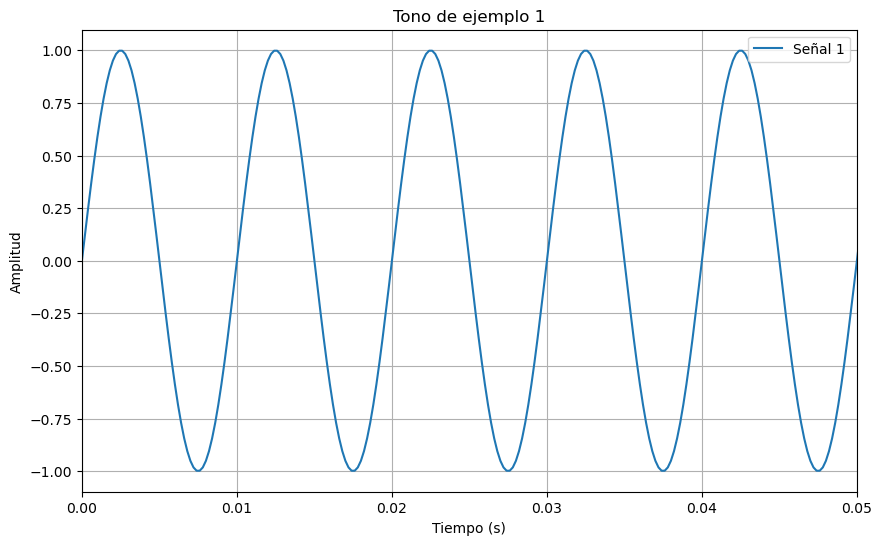

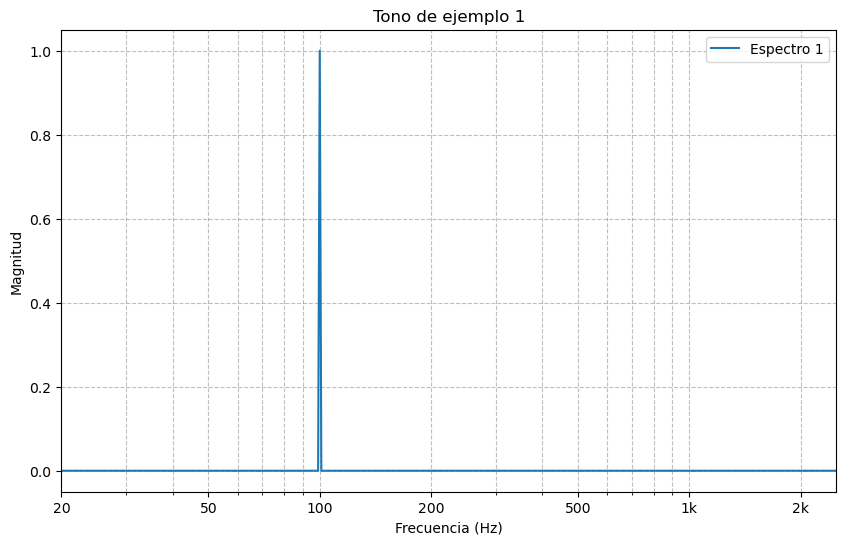

In [2]:
# Se llama a la función para generar un tono puro a modo de ejemplo.
fs = 5000
amp_1 = 1
dur_1 = 1
f_1 = 100

tono_puro_1 = generar_tono_puro(amplitud=amp_1, duracion=dur_1, fs=fs, frecuencia=f_1)

# Se llama a la función para graficar tono_puro_1 en el tiempo y en la frecuencia. 
# (Se limita el rango de tiempo mostrado para apreciar la forma de onda).
graficar_t(fs=fs, señales=tono_puro_1, titulo='Tono de ejemplo 1', xlim=(0,0.05))
graficar_f(fs=fs, señales=tono_puro_1, titulo='Tono de ejemplo 1')

Se elaboró la función `sumar_senales` con el fin de obtener señales compuestas por más de un tono puro. 

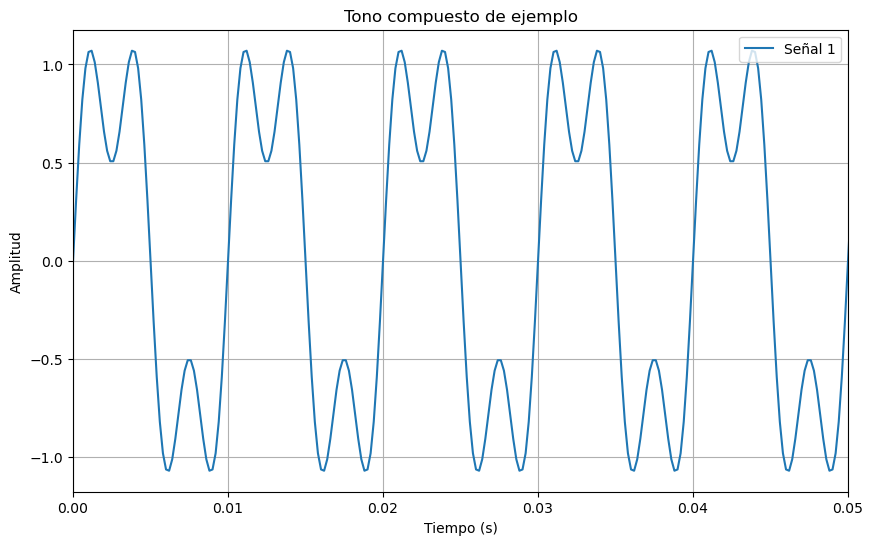

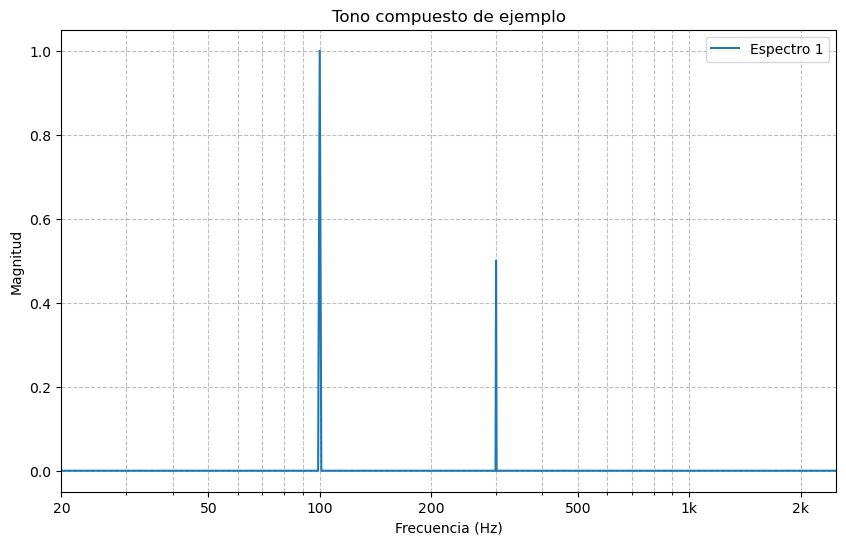

In [3]:
# Se prueba la función, generando un segundo tono *de misma duracion y fs, pero distinta amplitud y frecuencia fundamental) y sumándolo a tono_puro_1.
amp_2 = 0.5
f_2 = 300

tono_puro_2 = generar_tono_puro(amplitud=amp_2, duracion=dur_1, fs=fs, frecuencia=f_2)
senal_compuesta = sumar_senales(tono_puro_1, tono_puro_2)

# Se grafica la señal compuesta en el tiempo y en la frecuencia.
graficar_t(fs=fs, señales=senal_compuesta, titulo='Tono compuesto de ejemplo', xlim=(0,0.05))
graficar_f(fs=fs, señales=senal_compuesta, titulo='Tono compuesto de ejemplo')

Se elaboró la función `generar_ruido_blanco` para poder sumarla a las señales temporales. La amplitud puede ajustarse desde su parámetro "amplitud". 

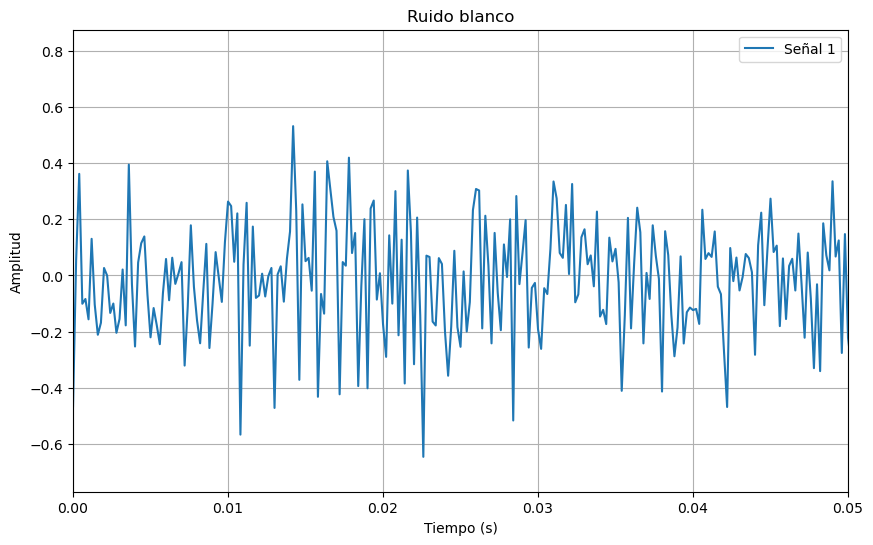

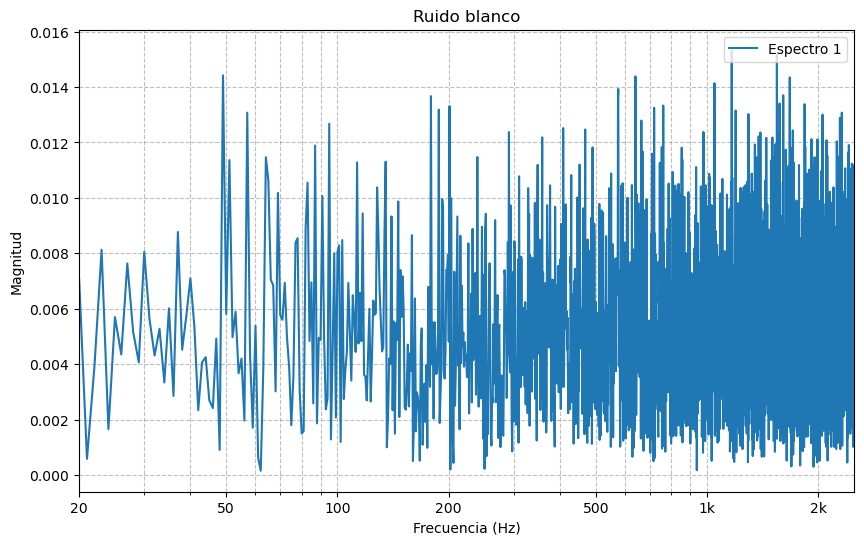

In [4]:
# Se llama a la función para generar ruido blanco a modo de ejemplo.
amp_rb = 0.8
ruido_blanco = generar_ruido_blanco(amplitud=amp_rb, duracion=dur_1, fs=fs)

# Se llama a la función para graficar ruido blanco, en el tiempo y en la frecuencia. 
graficar_t (fs=fs, señales=ruido_blanco, titulo="Ruido blanco", xlim=(0,0.05)) 
graficar_f (fs=fs, señales=ruido_blanco, titulo="Ruido blanco")


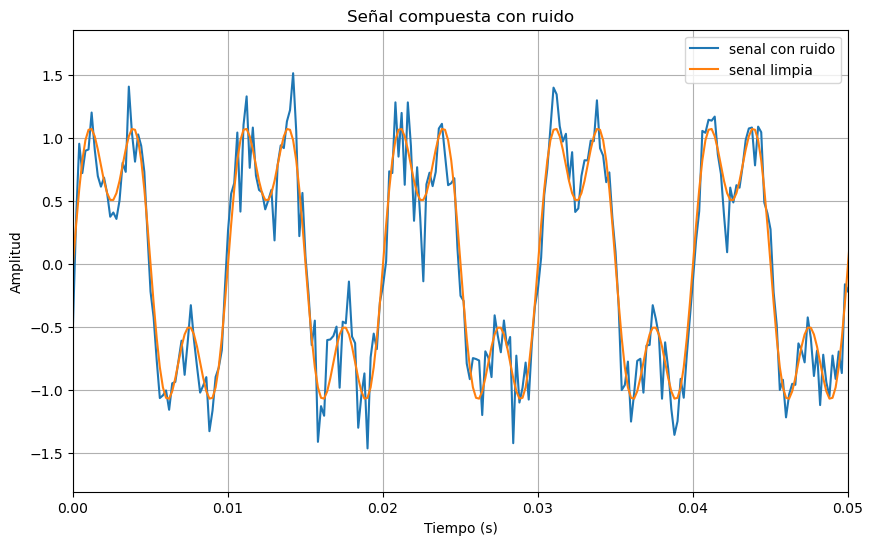

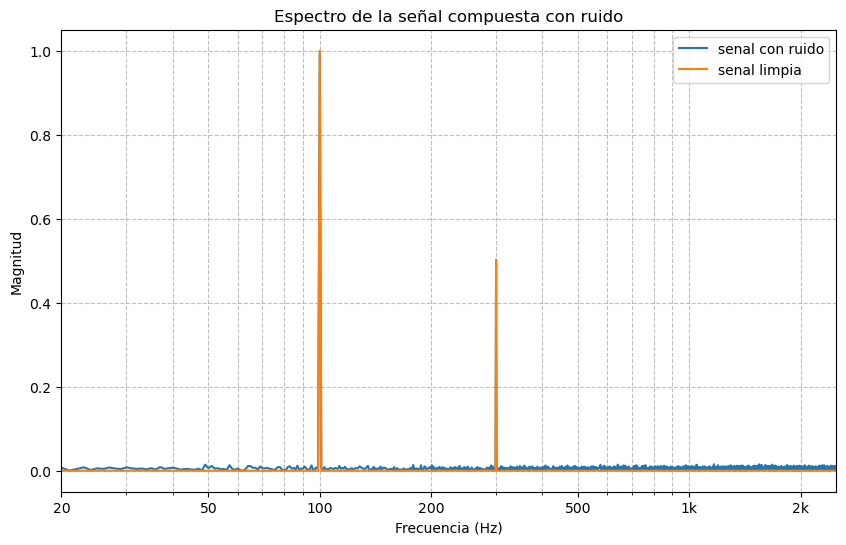

In [5]:
# Se suma el ruido blanco a la señal compuesta. 
senal_comp_ruido = sumar_senales(senal_compuesta, ruido_blanco) 

graficar_t (fs=fs, señales=[senal_comp_ruido, senal_compuesta], etiquetas=['senal con ruido', 'senal limpia'], titulo="Señal compuesta con ruido", xlim=(0,0.05))
graficar_f (fs=fs, señales=[senal_comp_ruido, senal_compuesta], etiquetas=['senal con ruido', 'senal limpia'], titulo= "Espectro de la señal compuesta con ruido")

Se generó una señal musical a partir de la función `generar_arpegio`. A esta señal también se le puede sumar ruido blanco de amplitud variable. 

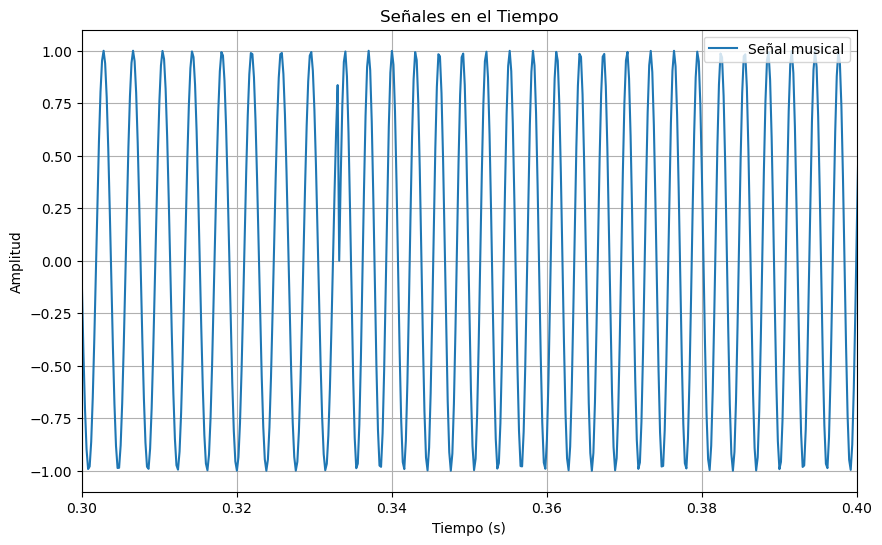

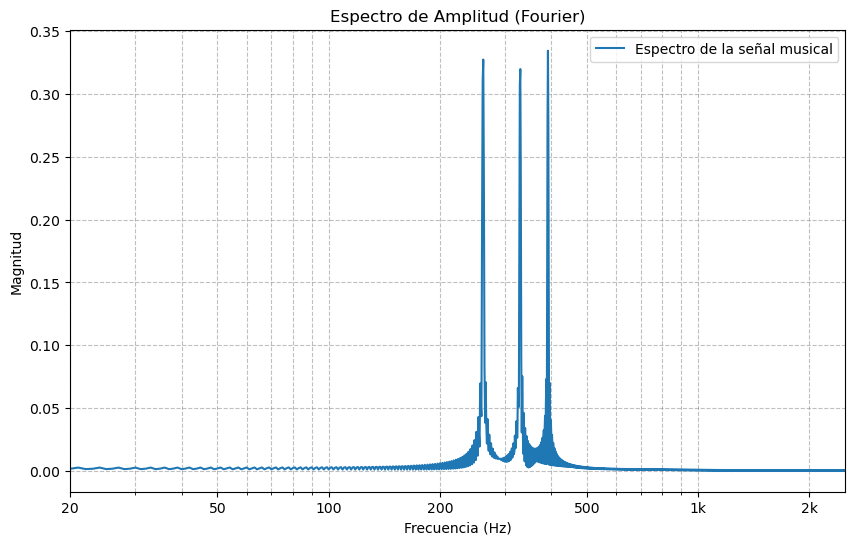

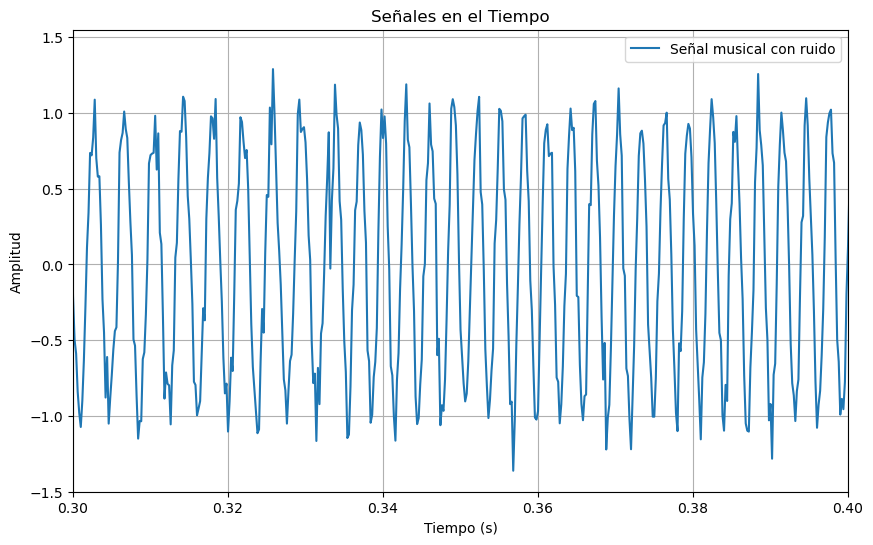

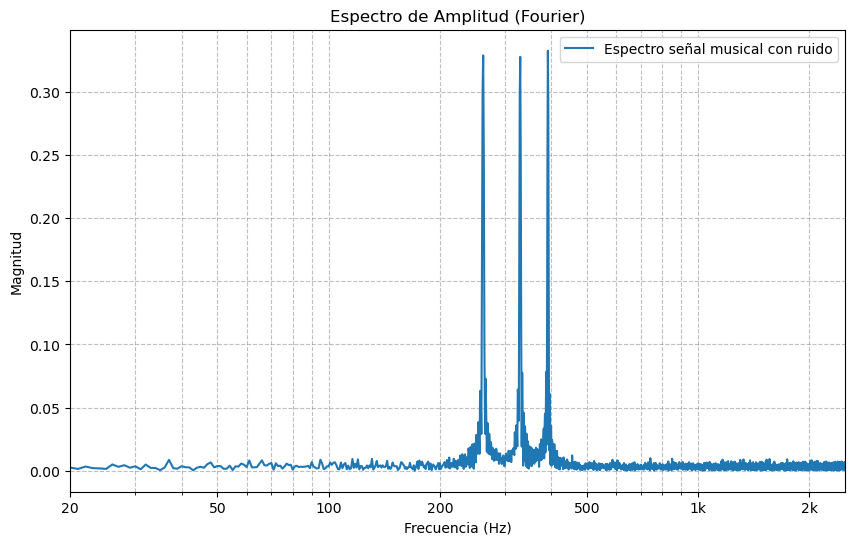

In [6]:
# Se genera una señal musical con un arpegio. 
señal_musical = generar_arpegio(dur_1, fs, 261.63, 329.63, 392.00)

# Se genera ruido blanco y se suma a la señal musical.
ruido_blanco_2 = generar_ruido_blanco(amplitud=0.5, duracion=dur_1, fs=fs)
señal_musical_ruido = sumar_senales(señal_musical, ruido_blanco_2)

# Se grafican ambas señales en tiempo y frecuencia.
graficar_t(fs, señal_musical, "Señal musical", xlim=(0.3,0.4))
graficar_f(fs, señal_musical, "Espectro de la señal musical")

graficar_t(fs, señal_musical_ruido, "Señal musical con ruido", xlim=(0.3,0.4))
graficar_f(fs, señal_musical_ruido, "Espectro señal musical con ruido")

### 1.2 Determinar la respuesta en frecuencia de un sistema 

Se generó la función `respuesta_f`, que permite encontrar la respuesta en frecuencia de un sistema, a partir de un par de señales de entrada y salida. 
La visualizacion de magnitud y fase se realiza con la funcion `graficar_analisis`.

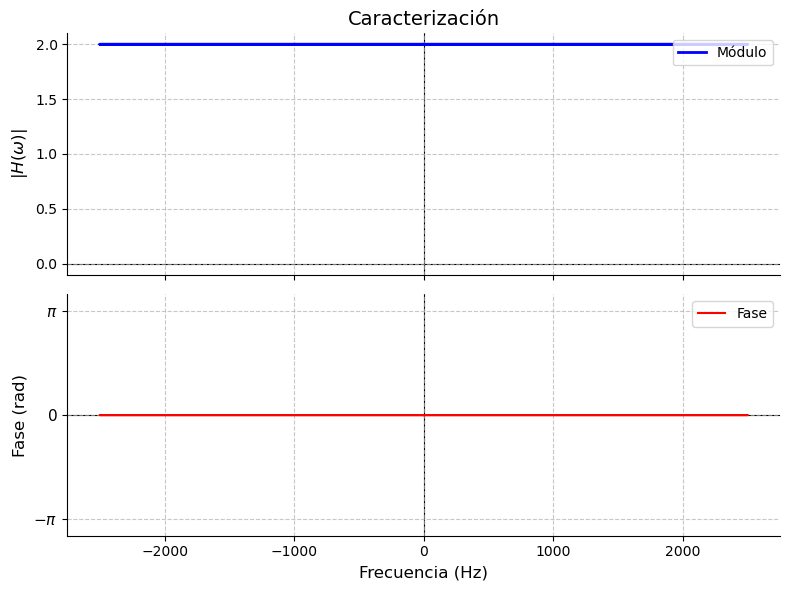

In [7]:
# Se prueba la función. Para ello, se genera un nuevo tono puro, y otro con el doble de amplitud. 
tono_puro_a1 = generar_tono_puro(amplitud=1, duracion=1, fs=fs, frecuencia=500)
tono_puro_a2 = generar_tono_puro(amplitud=2, duracion=1, fs=fs, frecuencia=500)

# Se llama a la función con el tono de mayor amplitud como salida, y el tono de menor amplitud como entrada. 
freqs_amp, magnitud_amp, fase_amp = respuesta_f(entrada=tono_puro_a1, salida=tono_puro_a2, fs=fs)

# Se grafica la respuesta en frecuencia del amplificador. 
graficar_analisis(freqs_amp, magnitud_amp, fase_amp)

### 1.3. RESPUESTA AL IMPULSO DE LOS FILTROS
A continuación, para seguir con el análisis, se buscará definir la respuesta al impulso de distintos filtros comunes en el procesamiento de señales.

A partir de este punto del trabajo, se trabajará con frecuencia de muestreo 44100 Hz.

In [8]:
fs2 = 44100

Filtro media móvil: $h[n] = \frac{1}{M}$, siendo $M$ el largo de la ventana.
* h1, h2 y h3 corresponden a la respuesta al impulso despues de una, dos y tres pasadas del mismo respectivamente. 

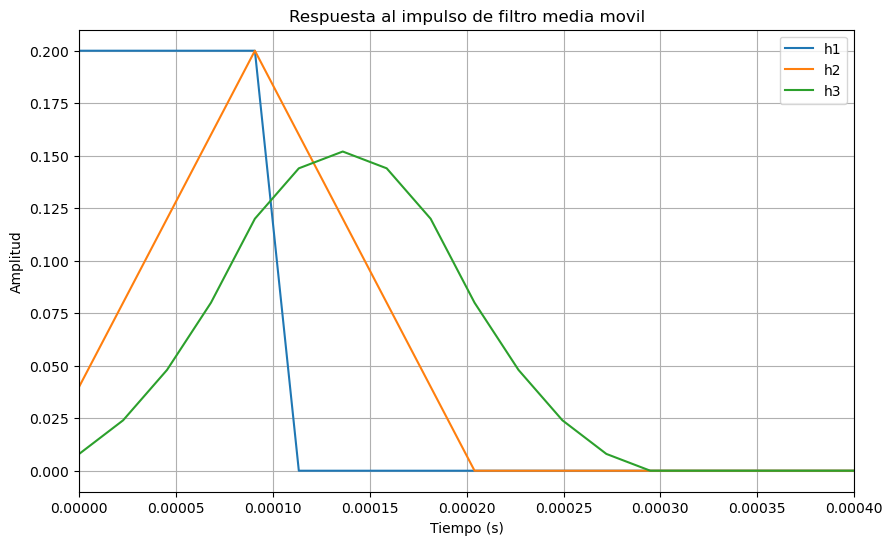

In [9]:
h1, h2, h3 = filtros_media_movil(M=5, N=512)
graficar_t(fs2, señales=[h1,h2,h3], etiquetas=['h1','h2','h3'], titulo='Respuesta al impulso de filtro media movil', xlim=(0,0.0004))

Filtro peine: $h[n] = b_0\delta[n] + b_1\delta[n - 1] + b_2\delta[n - 2]$, donde $b_0$, $b_1$ y $b_2$ son coeficientes constantes.

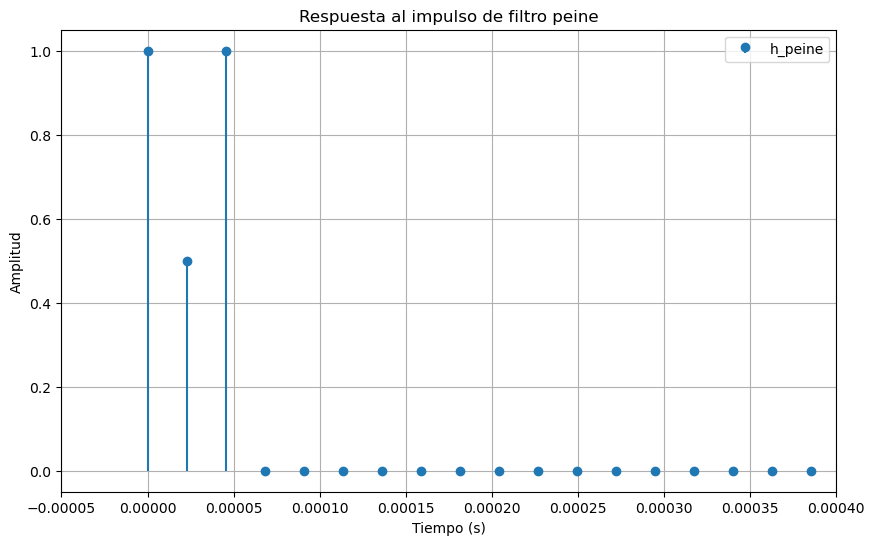

In [10]:
h_peine = filtro_peine(b0=1, b1=0.5, b2=1, N=512)
graficar_t(fs2, h_peine, etiquetas=['h_peine'], titulo='Respuesta al impulso de filtro peine', xlim=(-0.00005,0.0004), modo='discreto')

Filtro respuesta al impulso finita, realizada con coeficientes provistos por la catedra:

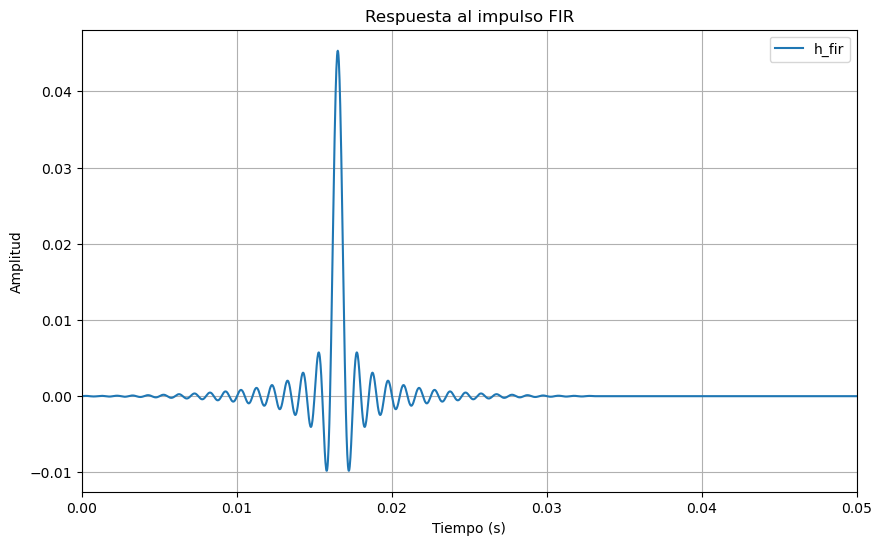

In [11]:
h_fir = filtro_fir(N=3000, path='Datos/archivos_tp1c2026/fir_hamming_1000Hz.npy')
graficar_t(fs2, h_fir, etiquetas=['h_fir'], titulo='Respuesta al impulso FIR', xlim=(0,0.05))

### 1.4 CARACTERIZACION EN FRECUENCIA DE LOS FILTROS

Luego, se caracteriza a los filtros en funcion a su respuesta en frecuencia en modulo y fase.

La funcion `analisis_filtros` devuelve un array de valores de modulo y uno de valores de fase, ademas de un array de frecuencias para lograr una representacion grafica concisa, utilizando la funcion `graficar_analisis`.

#### FILTRO DE MEDIA MOVIL

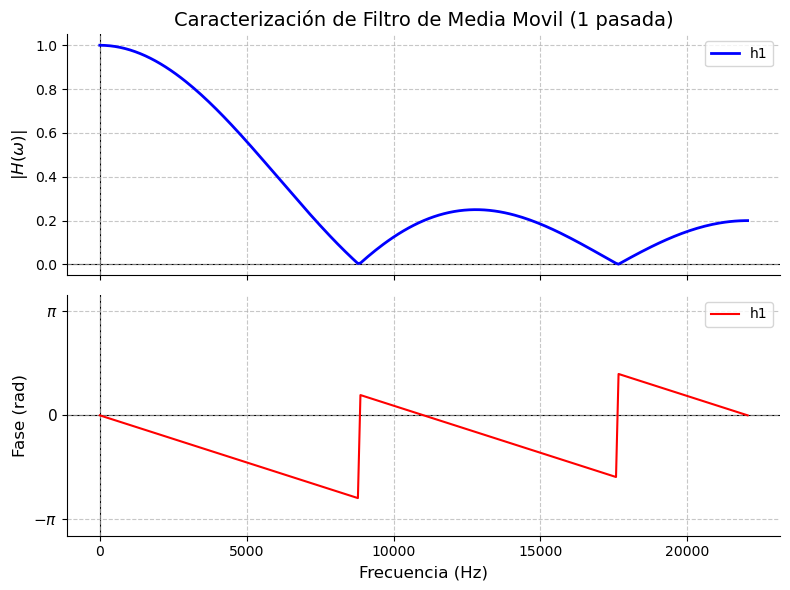

In [12]:
# FILTRO DE MEDIA MOVIL DE UNA PASADA
freq_h1, mod_h1, fase_h1 = analisis_filtros(h1, fs2)
graficar_analisis(freq_h1, mod_h1, fase_h1, etiquetas='h1', titulo='Caracterización de Filtro de Media Movil (1 pasada)')

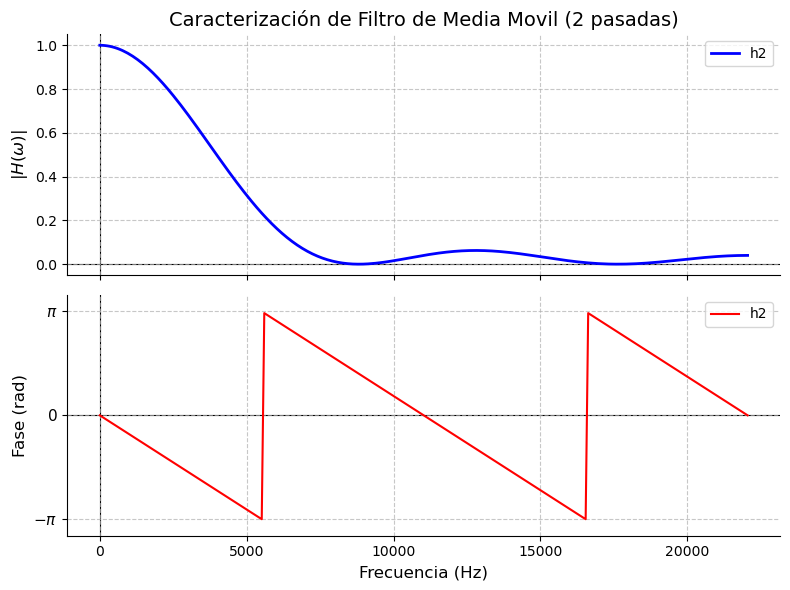

In [13]:
# FILTRO DE MEDIA MOVIL DE DOS PASADAS
freq_h2, mod_h2, fase_h2 = analisis_filtros(h2, fs2)
graficar_analisis(freq_h2, mod_h2, fase_h2, etiquetas='h2', titulo='Caracterización de Filtro de Media Movil (2 pasadas)')

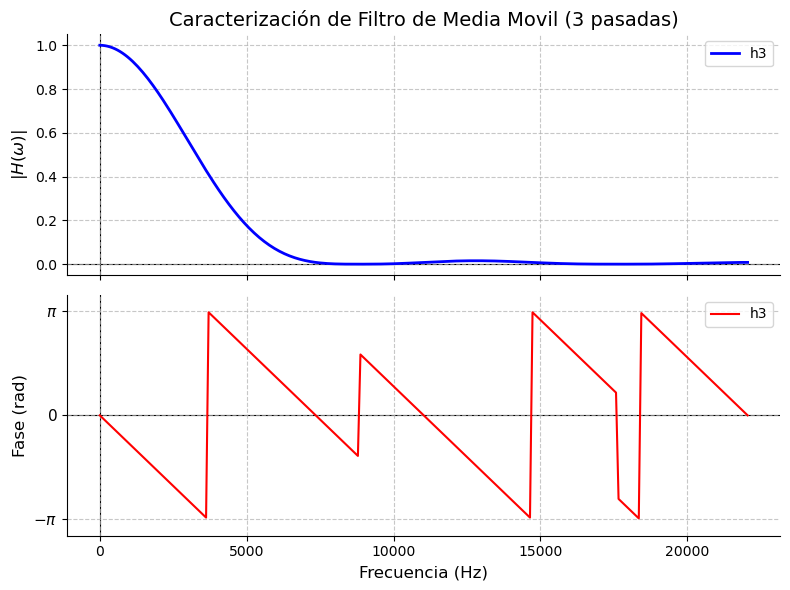

In [14]:
# FILTRO DE MEDIA MOVIL DE TRES PASADAS
freq_h3, mod_h3, fase_h3 = analisis_filtros(h3, fs2)
graficar_analisis(freq_h3, mod_h3, fase_h3, etiquetas='h3', titulo='Caracterización de Filtro de Media Movil (3 pasadas)')

##### ANÁLISIS DE FILTROS DE MEDIA MOVIL:

* Respuesta al impulso: La respuesta al impulso de un filtro de media movil, corresponde a una ventana temporal, donde la amplitud de la respuesta se define por el promedio de la amplitud de las muestras que ingresan en la ventana. De esta forma se observa un suavizado de los picos de la señal, que se hace mas notorio a medida que se aumentan las pasadas. Al pasar dos veces el filtro, se convolucionan dos ventanas rectangulares del mismo tamaño y la misma amplitud, por lo que se obtiene una ventana triangular, y finalmente en la tercera pasada se convoluciona una ventana rectangular con el resultado triangular de la segunda pasada, por lo que se obtiene un promedio en forma de campana como resultado.

* Respuesta en frecuencia:
    * Módulo: La respuesta en frecuencia esperada de una ventana rectangular, tiene forma de sinc, y es lo que se ve expresado en los graficos de módulo de las señales. A medida que aumentan las pasadas, este se va suavizando en los lóbulos secundarios. En todos los casos, se observa que el comportamiento es el de un filtro pasabajos. Esto se da por el comportamiento de promediado del filtro, que suaviza los cambios rápidos, es decir atenúa las frecuencias altas.  
    * Fase: La fase de la respuesta en frecuencia es lineal, con cambios abruptos en dos casos. En primer lugar, la señal pasa de -$\pi$ a $\pi$, y viceversa, porque el gráfico de la misma se mantiene dentro del argumento principal (la fase es periódica en $2\pi$). En segundo lugar, se observan cambios de fase en los ceros del módulo de la respuesta en frecuencia, dada la indeterminación que se produce. El retraso de grupo es, entonces, constante dado que se mantiene la pendiente de la fase.

#### FILTRO PEINE

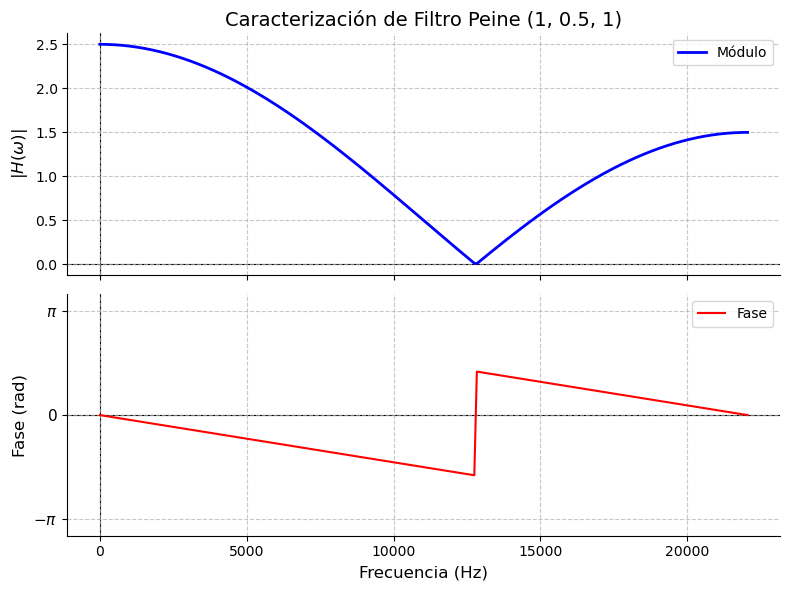

In [15]:
# FILTRO PEINE
freq_peine, mod_peine, fase_peine = analisis_filtros(h_peine, fs2)
graficar_analisis(freq_peine, mod_peine, fase_peine, titulo='Caracterización de Filtro Peine (1, 0.5, 1)')

##### ANÁLISIS DE FILTRO PEINE:

* Respuesta al impulso: Se observa en el gráfico de la respuesta al impulso que se atenúa o amplifica la amplitud en función de los parámetros $b0$, $b1$ y $b2$ ingresados. Al ingresar un pulso, la salida en $n=0$ está determinada por $b0$, la salida en $n=1$ está determinada por $b1$ y la salida en $n=2$ está determinada por $b2$. 

* Respuesta en frecuencia:
    * Módulo: Dependiendo de los coeficientes ingresados, las frecuencias se sumarán de forma desctructiva o constructiva, en función de la diferencia de fase entre la señales desplazadas y la amplitud asignada a las mismas. En este sentido, el módulo de la respuesta en frecuencia evidenciará la amplificación o atenuación que experimentará el espectro. 
    * Fase: De igual manera, una variación en la amplitud del comportamiento en frecuencia de la señal, genera a su vez una modificación en su comportamiento de fase. 

#### FILTRO FIR

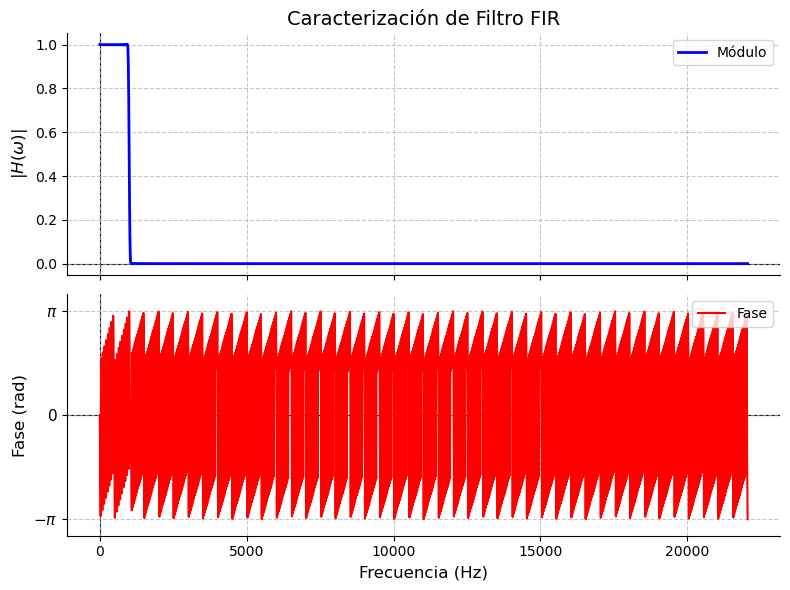

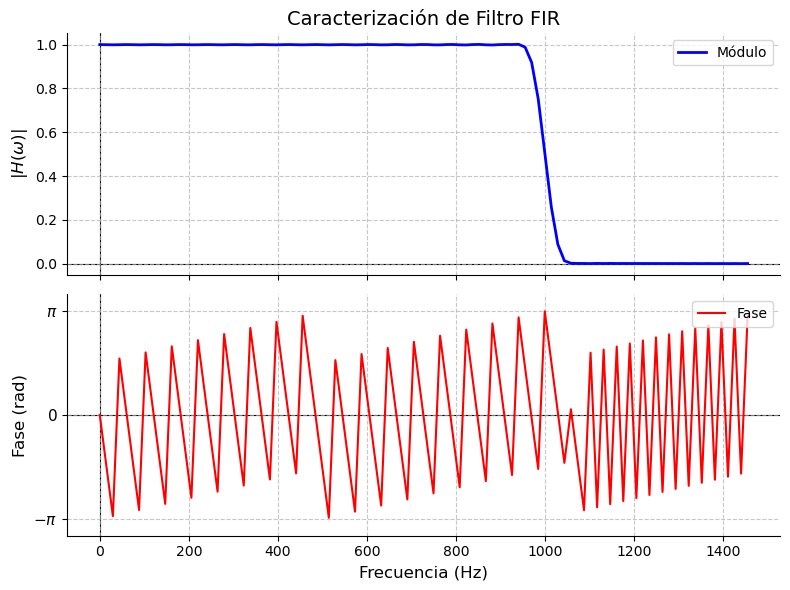

In [16]:
#FILTRO FIR
freq_fir, mod_fir, fase_fir = analisis_filtros(h_fir, fs2)
graficar_analisis(freq_fir, mod_fir, fase_fir, titulo='Caracterización de Filtro FIR')

#ZOOM EN LAS PRIMERAS 100 DIVISIONES
graficar_analisis(freq_fir[:100], mod_fir[:100], fase_fir[:100], titulo='Caracterización de Filtro FIR')

##### ANÁLISIS DE FILTRO FIR:

* Respuesta al impulso: Se observa en el gráfico de la respuesta al impulso un comportamiento de tipo sinc.

* Respuesta en frecuencia:
    * Módulo: Se puede identificar un comportamiendo de pasabajos, con frecuencia de corte en 1000 Hz. Es un comportamiento que coincide con la respuesta al impulso observada.
    * Fase: 

### 1.5 VARIACIÓN DE PARÁMETROS EN LOS FILTROS

#### FILTRO PEINE

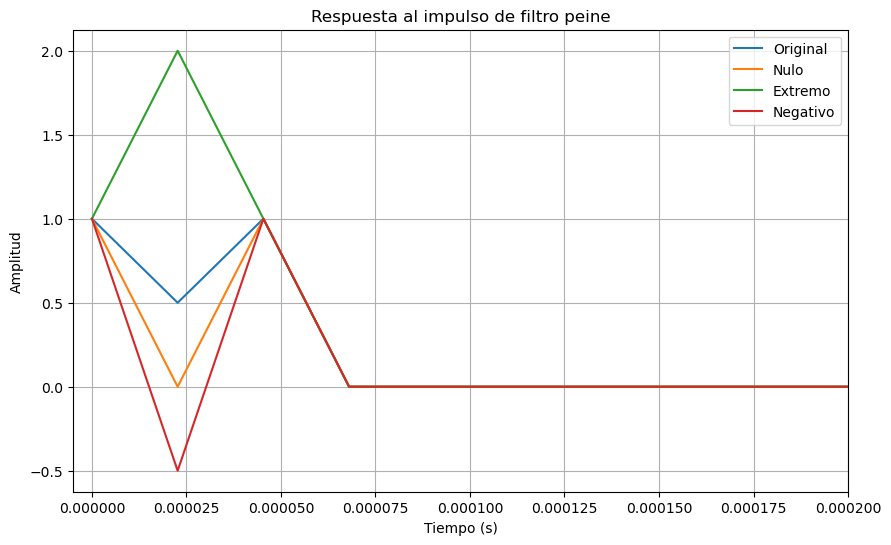

In [17]:
# VARIACION DE LA PRIMERA SENAL RETRASADA DEL FILTRO PEINE (se varia el valor de B1)
# RECORDANDO QUE: h_peine = filtro_peine(b0=1, b1=0.5, b2=1, N=512)
h_peine_b1nulo = filtro_peine(b0=1, b1=0, b2=1, N=512)
h_peine_b1extremo = filtro_peine(b0=1, b1=2, b2=1, N=512)
h_peine_b1neg = filtro_peine(b0=1, b1=-0.5, b2=1, N=512)

#Se grafican las 3 respuestas al impulso.
graficar_t(fs2, señales=[h_peine,h_peine_b1nulo,h_peine_b1extremo,h_peine_b1neg], titulo='Respuesta al impulso de filtro peine',etiquetas=['Original', 'Nulo', 'Extremo', 'Negativo'], xlim=(-0.000005,0.0002))

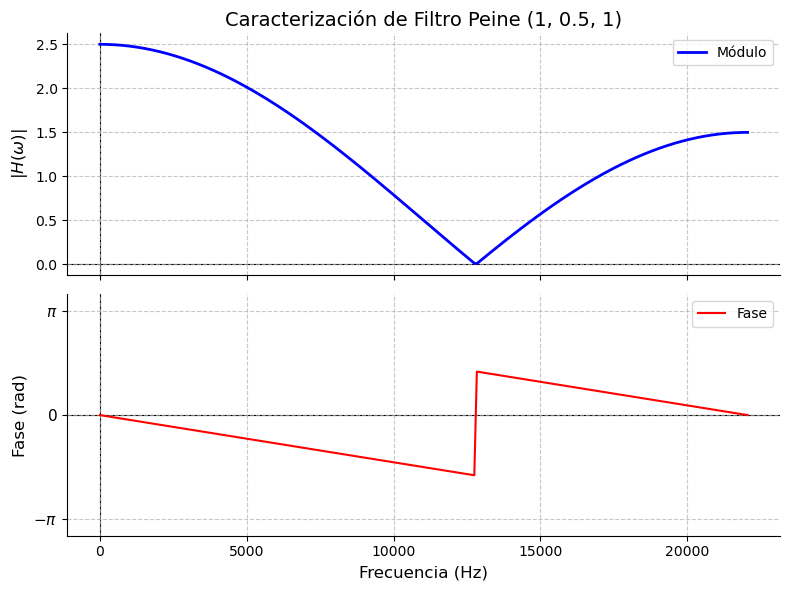

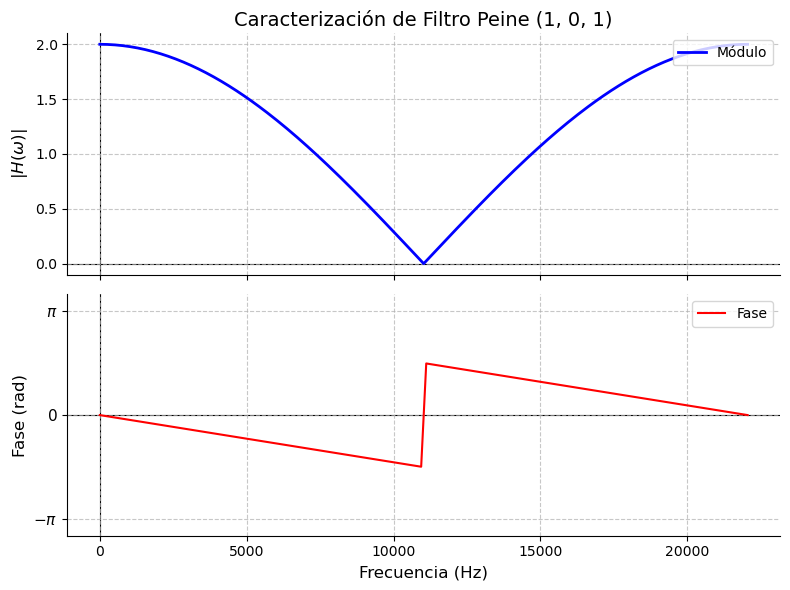

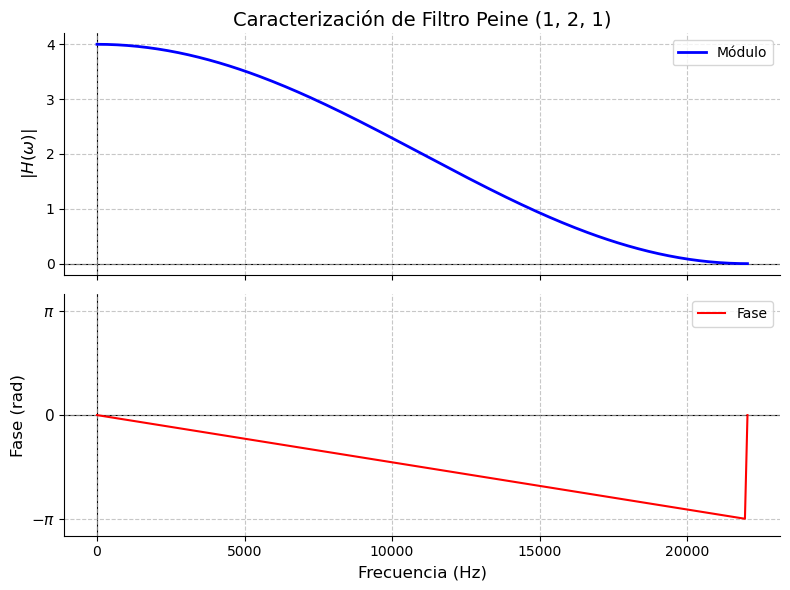

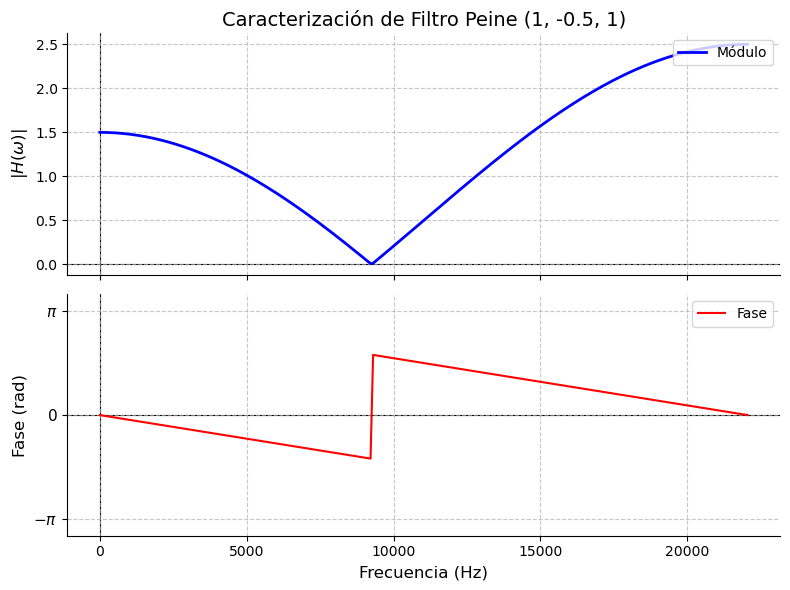

In [18]:
#Se grafican por separado las 4 respuestas en frecuencia.
graficar_analisis(freq_peine, mod_peine, fase_peine, titulo='Caracterización de Filtro Peine (1, 0.5, 1)')

freq_peine_b1nulo, mod_peine_b1nulo, fase_peine_b1nulo = analisis_filtros(h_peine_b1nulo, fs2)
graficar_analisis(freq_peine_b1nulo, mod_peine_b1nulo, fase_peine_b1nulo, titulo='Caracterización de Filtro Peine (1, 0, 1)')

freq_peine_b1extremo, mod_peine_b1extremo, fase_peine_b1extremo = analisis_filtros(h_peine_b1extremo, fs2)
graficar_analisis(freq_peine_b1extremo, mod_peine_b1extremo, fase_peine_b1extremo, titulo='Caracterización de Filtro Peine (1, 2, 1)')

freq_peine_b1neg, mod_peine_b1neg, fase_peine_b1neg = analisis_filtros(h_peine_b1neg, fs2)
graficar_analisis(freq_peine_b1neg, mod_peine_b1neg, fase_peine_b1neg, titulo='Caracterización de Filtro Peine (1, -0.5, 1)')

Puede verse como comportamiento que la variación del parámetro B1, modifica la amplitud total del lóbulo principal. En frecuencias bajas la amplitud del filtro peine tienda a las suma de las 3 señales, porque un retraso de una o dos muestras temporales, no debería ser significante y afectar el comportamiento en esa zona. Tambien notamos que la fase en bajas frecuencias es 0.

Por otro lado, se nota que la frecuencia donde se haya la cancelación, se comporta análogamente al valor de B1. Con un menor valor de B1, se encuentra en un valor de menor frecuencia, y a medida que B1 aumenta, la ubicación de la zona de cancelación aumenta también.


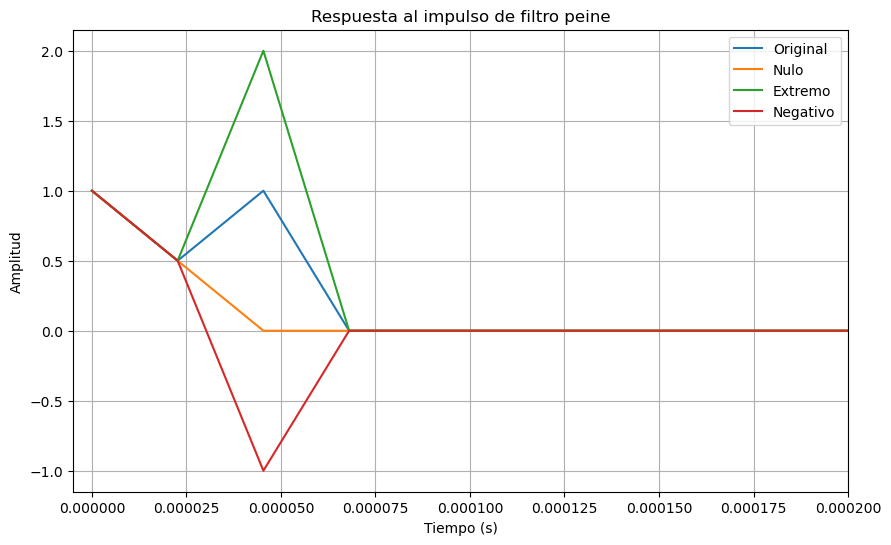

In [19]:
# VARIACION DE LA SEGUNDA SENAL RETRASADA DEL FILTRO PEINE (se varia el valor de B2)
# RECORDANDO QUE: h_peine = filtro_peine(b0=1, b1=0.5, b2=1, N=512)
h_peine_b2nulo = filtro_peine(b0=1, b1=0.5, b2=0, N=512)
h_peine_b2extremo = filtro_peine(b0=1, b1=0.5, b2=2, N=512)
h_peine_b2neg = filtro_peine(b0=1, b1=0.5, b2=-1, N=512)

#Se grafican las 3 respuestas al impulso.
graficar_t(fs2, señales=[h_peine,h_peine_b2nulo,h_peine_b2extremo,h_peine_b2neg], titulo='Respuesta al impulso de filtro peine',etiquetas=['Original', 'Nulo', 'Extremo', 'Negativo'], xlim=(-0.000005,0.0002))

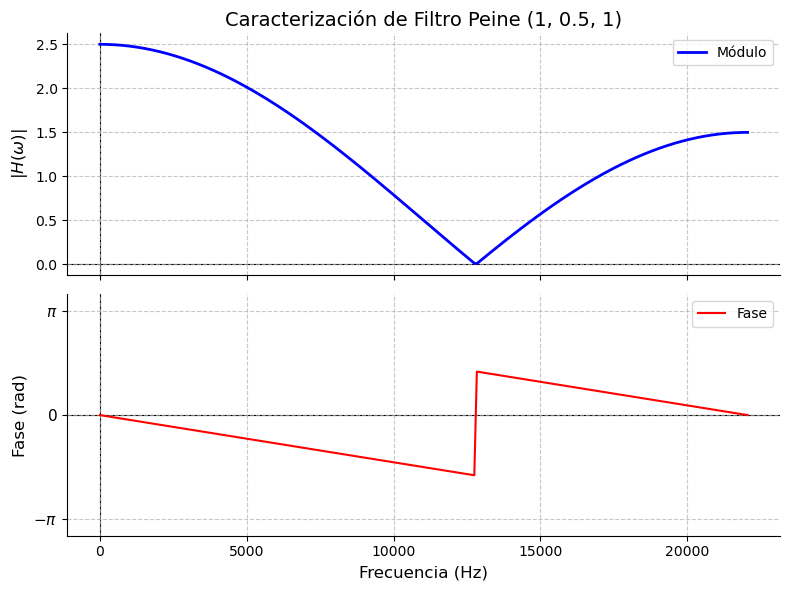

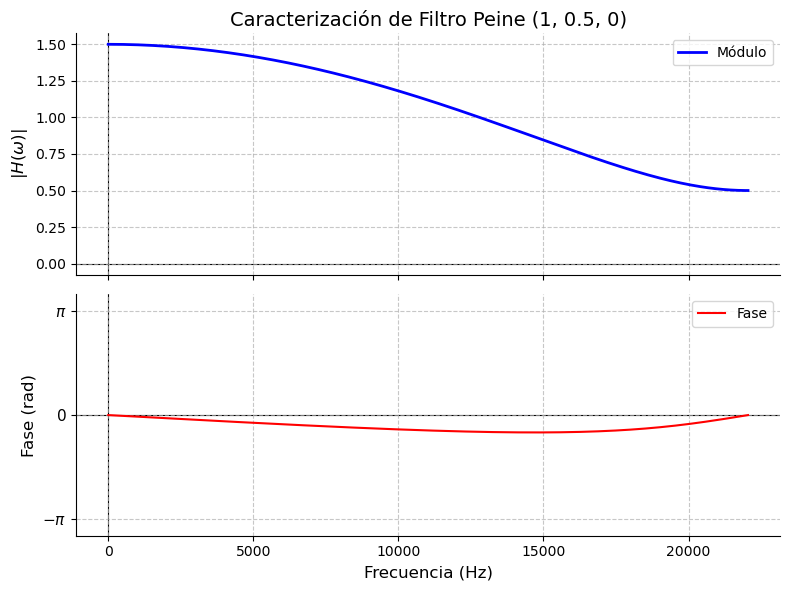

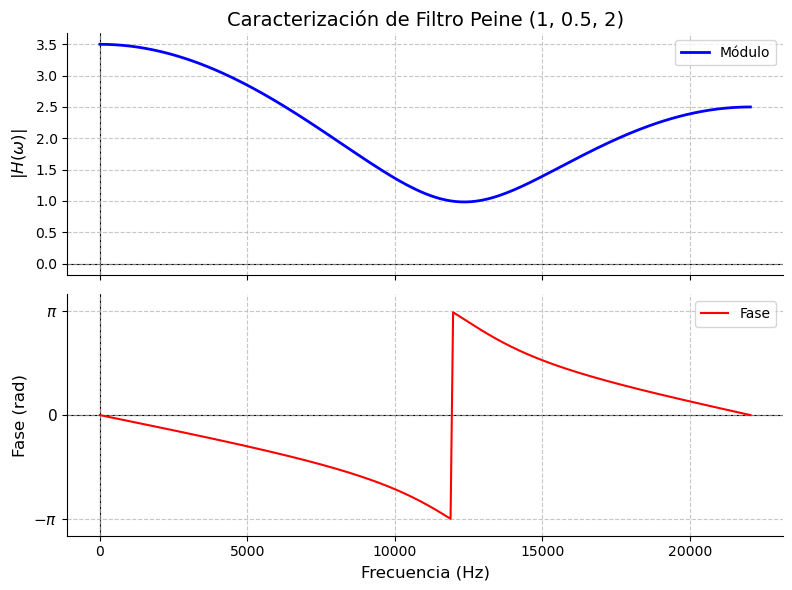

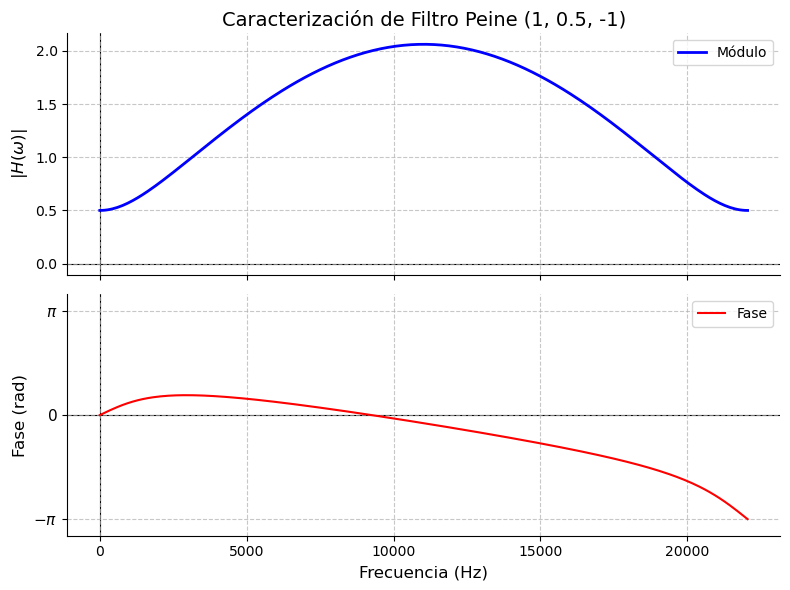

In [20]:
#Se grafican por separado las 4 respuestas en frecuencia.
graficar_analisis(freq_peine, mod_peine, fase_peine, titulo='Caracterización de Filtro Peine (1, 0.5, 1)')

freq_peine_b2nulo, mod_peine_b2nulo, fase_peine_b2nulo = analisis_filtros(h_peine_b2nulo, fs2)
graficar_analisis(freq_peine_b2nulo, mod_peine_b2nulo, fase_peine_b2nulo, titulo='Caracterización de Filtro Peine (1, 0.5, 0)')

freq_peine_b2extremo, mod_peine_b2extremo, fase_peine_b2extremo = analisis_filtros(h_peine_b2extremo, fs2)
graficar_analisis(freq_peine_b2extremo, mod_peine_b2extremo, fase_peine_b2extremo, titulo='Caracterización de Filtro Peine (1, 0.5, 2)')

freq_peine_b2neg, mod_peine_b2neg, fase_peine_b2neg = analisis_filtros(h_peine_b2neg, fs2)
graficar_analisis(freq_peine_b2neg, mod_peine_b2neg, fase_peine_b2neg, titulo='Caracterización de Filtro Peine (1, 0.5, -1)')

Al variar el parámetro B2, por un lado se sigue concluyendo que el comportamiento en bajas frecuencias tiende a la suma de los valores de los tres parámetros. En caso en el que B2=0 (y B0 es distinto de B1), se observa que no hay ninguna frecuencia con cancelación completa (mientras que en las sección anterior, si se observó una cancelación completa en todos los casos).

Se observa tambien que mientras mas cercanos sean $b0$ y $b2$, mas tendencia tiene la fase a comportarse de manera lineal.

#### FILTRO DE MEDIA MOVIL

In [21]:
# VARIACION DEL ANCHO DE LA VENTANA (SE VARIA EL PARAMETRO M)
# RECORDANDO QUE LAS 3 PASADAS ORIGINALES SON: h1, h2, h3 = filtros_media_movil(M=5, N=512)

h1_corto, h2_corto, h3_corto = filtros_media_movil(M=2, N=512)
h1_largo, h2_largo, h3_largo = filtros_media_movil(M=10, N=512)

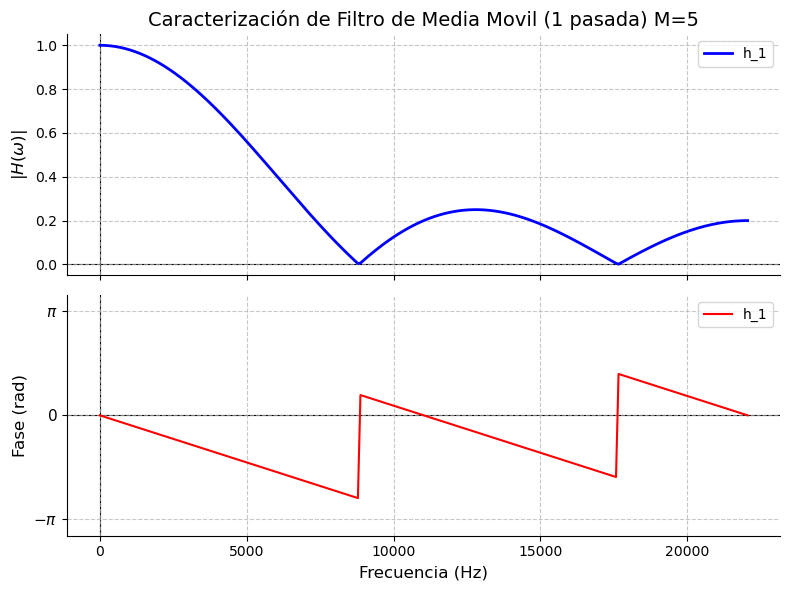

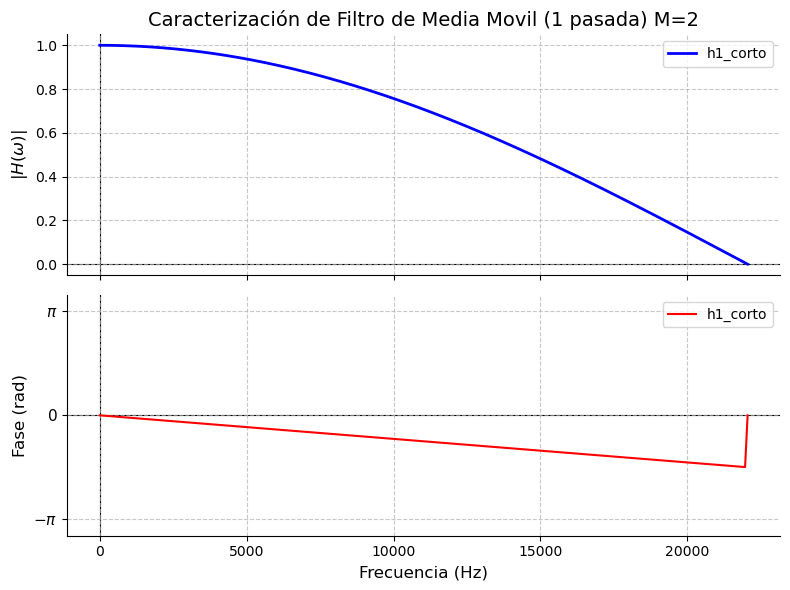

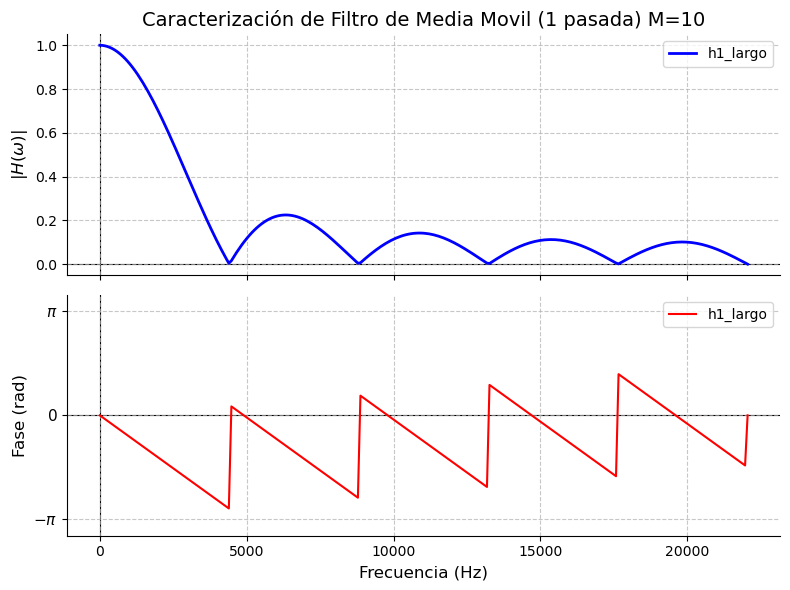

In [22]:
graficar_analisis(freq_h1, mod_h1, fase_h1, etiquetas='h_1', titulo='Caracterización de Filtro de Media Movil (1 pasada) M=5')

freq_h1_corto, mod_h1_corto, fase_h1_corto = analisis_filtros(h1_corto, fs2)
graficar_analisis(freq_h1_corto, mod_h1_corto, fase_h1_corto, etiquetas='h1_corto', titulo='Caracterización de Filtro de Media Movil (1 pasada) M=2')

freq_h1_largo, mod_h1_largo, fase_h1_largo = analisis_filtros(h1_largo, fs2)
graficar_analisis(freq_h1_largo, mod_h1_largo, fase_h1_largo, etiquetas='h1_largo', titulo='Caracterización de Filtro de Media Movil (1 pasada) M=10')

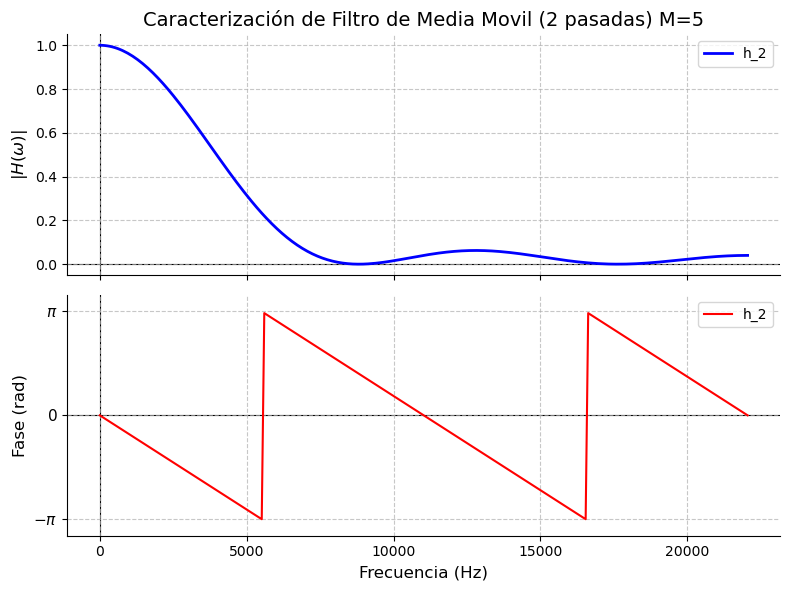

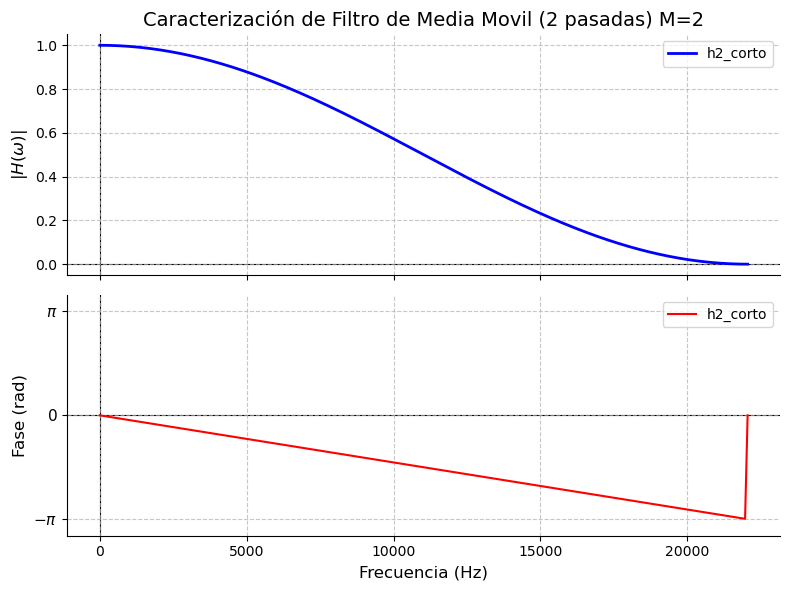

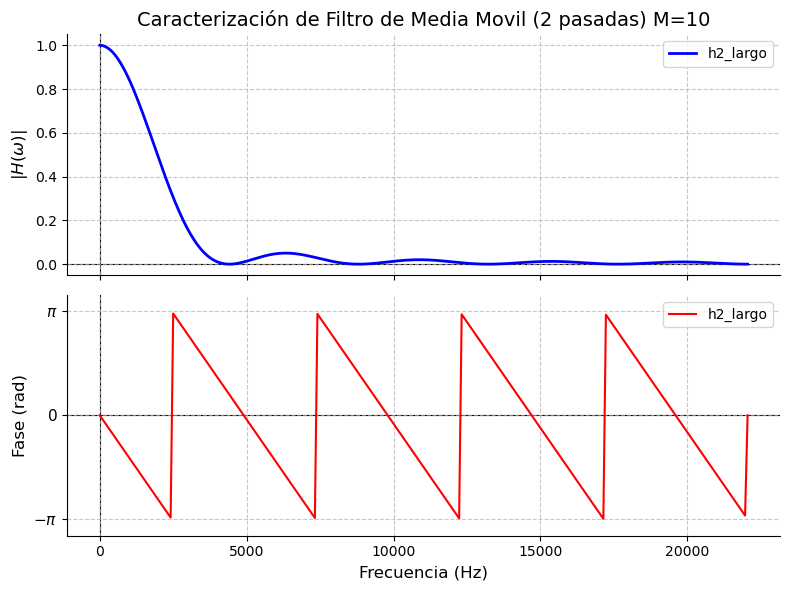

In [23]:
graficar_analisis(freq_h2, mod_h2, fase_h2, etiquetas='h_2', titulo='Caracterización de Filtro de Media Movil (2 pasadas) M=5')

freq_h2_corto, mod_h2_corto, fase_h2_corto = analisis_filtros(h2_corto, fs2)
graficar_analisis(freq_h2_corto, mod_h2_corto, fase_h2_corto, etiquetas='h2_corto', titulo='Caracterización de Filtro de Media Movil (2 pasadas) M=2')

freq_h2_largo, mod_h2_largo, fase_h2_largo = analisis_filtros(h2_largo, fs2)
graficar_analisis(freq_h2_largo, mod_h2_largo, fase_h2_largo, etiquetas='h2_largo', titulo='Caracterización de Filtro de Media Movil (2 pasadas) M=10')

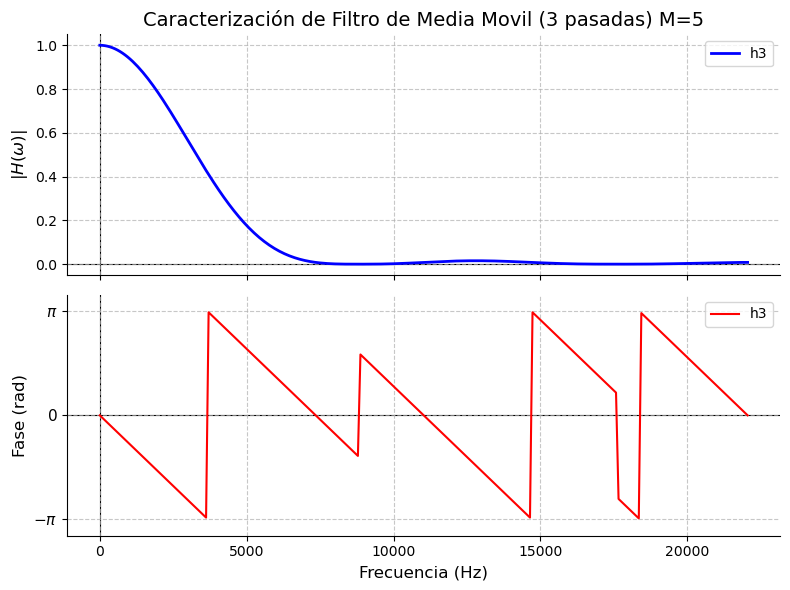

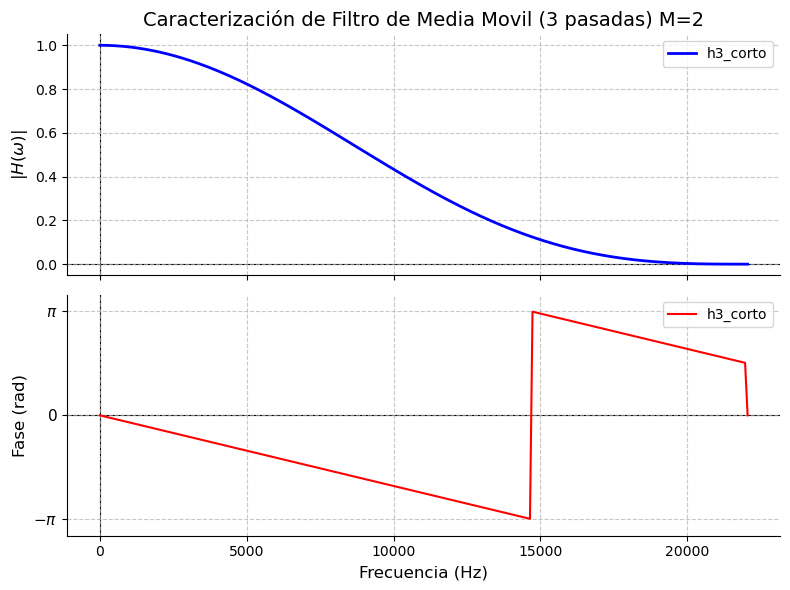

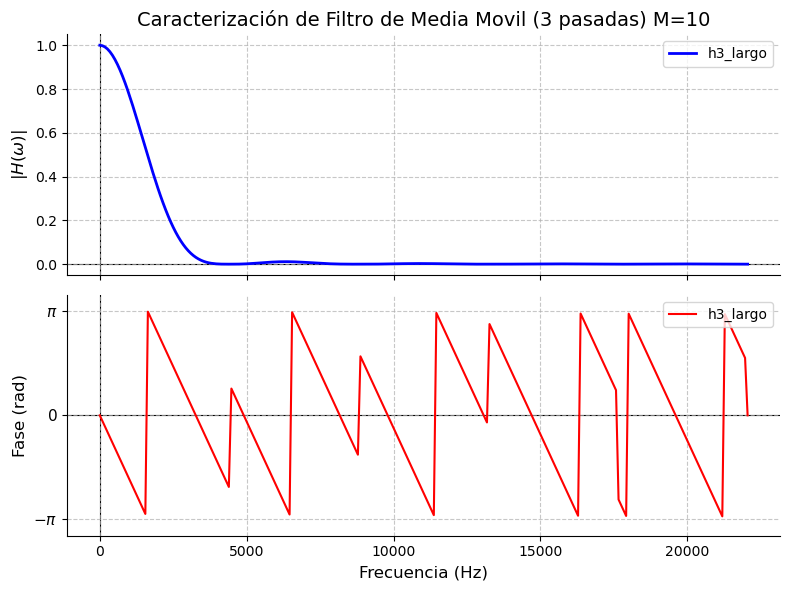

In [24]:
graficar_analisis(freq_h3, mod_h3, fase_h3, etiquetas='h3', titulo='Caracterización de Filtro de Media Movil (3 pasadas) M=5')

freq_h3_corto, mod_h3_corto, fase_h3_corto = analisis_filtros(h3_corto, fs2)
graficar_analisis(freq_h3_corto, mod_h3_corto, fase_h3_corto, etiquetas='h3_corto', titulo='Caracterización de Filtro de Media Movil (3 pasadas) M=2')

freq_h3_largo, mod_h3_largo, fase_h3_largo = analisis_filtros(h3_largo, fs2)
graficar_analisis(freq_h3_largo, mod_h3_largo, fase_h3_largo, etiquetas='h3_largo', titulo='Caracterización de Filtro de Media Movil (3 pasadas) M=10')

En la primera pasada se nota que al achicar el valor de la ventana M, el filtro se vuelve menos selectivo, es decir se ensancha el lobulo principal. Mientras que si se agranda el valor de M, se obtiene un lóbulo principal mas angosto, y hay mas cantidad de lóbulos secundarios.

Con el correr de las pasadas, el efecto de todos los filtros es el mismo, se reducen las amplitudes de los lóbulos secundarios y se suaviza la forma del lóbulo principal.

### 1.6 FILTRADO DE SEÑALES

Ahora con el objetivo de relacionar las señales generadas y los filtros diseñados, se procede a filtrar las señales mediante dos tipos de procesos distintos. Primero, mediante la convolución en el dominio del tiempo y luego, utilizando la convolución circular y las propiedades de multiplicación en frecuencia.

En este inciso, se generarán nuevas señales con frecuencia de muestreo 44100 Hz, a diferencia de las ilustrativas de la primera parte cuya frecuencia de muestreo es 5000 Hz.

CONSIGNA: Filtrar las señales con los filtros diseñados y analizar los resultados. Hacerlo mediante convolución en el dominio del tiempo y mediante convolución circular en frecuencia (usar propiedades).

#### FILTRADO UTILIZANDO EL FILTRO PEINE (1, 0.5, 1).

##### SEÑAL MUSICAL CON RUIDO DE AMPLITUD 0.5

FILTRADO TEMPORAL

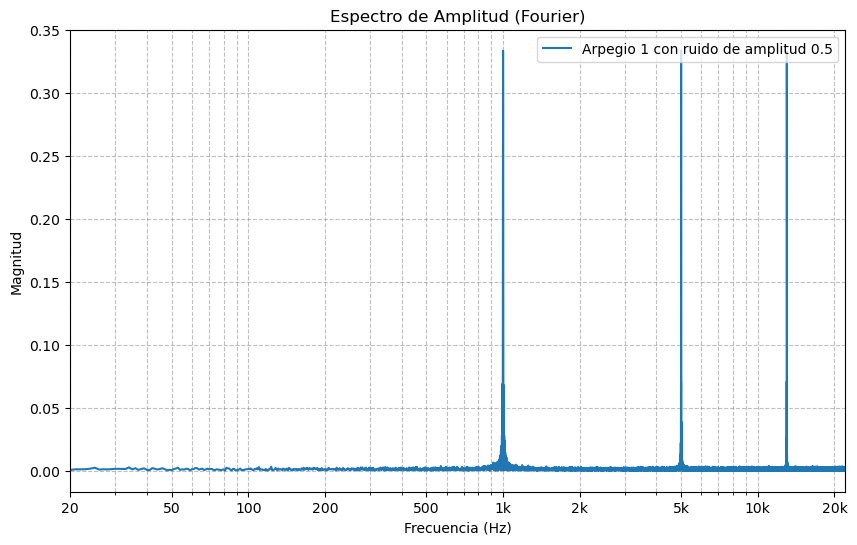

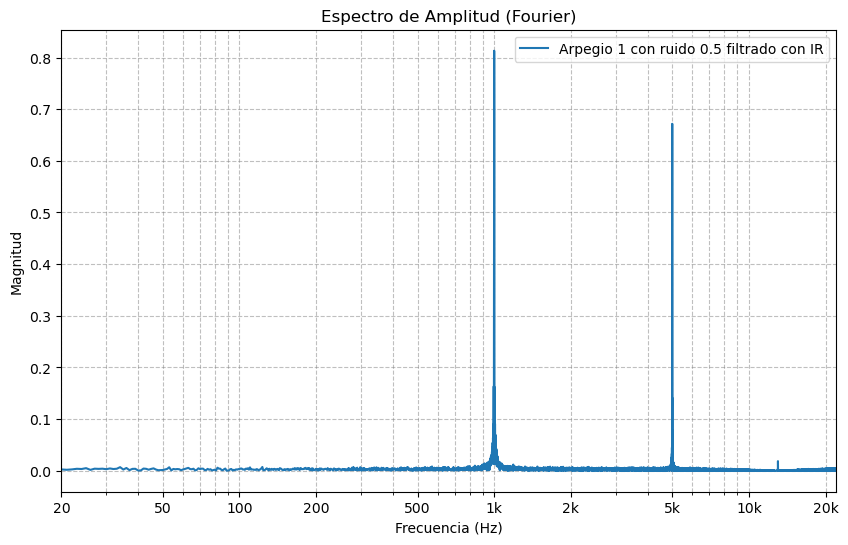

In [25]:
# SE GENERA UNA SEÑAL DE ARPEGIO DE 1 SEGUNDO CON RUIDO DE AMPLITUD 0.5 Y SE LA FILTRA UTILIZANDO LA RESPUESTA AL IMPULSO DEL FILTRO PEINE (1, 0.5, 1).
ruido_blanco_05= generar_ruido_blanco(amplitud=0.5, duracion=1, fs=fs2)
arpegio1 = generar_arpegio(1, fs2, 1000, 5000, 13000)
arpegio1_ruido05 = sumar_senales(arpegio1, ruido_blanco_05)
arpegio1_05_filtrado = filtrar_temporal(h_peine, arpegio1_ruido05)

# SE GRAFICA LA SENAL SIN FILTRAR Y LA SENAL FILTRADA.
graficar_f(fs2, arpegio1_ruido05, 'Arpegio 1 con ruido de amplitud 0.5')
graficar_f(fs2, arpegio1_05_filtrado, 'Arpegio 1 con ruido 0.5 filtrado con IR')

In [26]:
Audio(arpegio1_ruido05, rate=fs2)

In [27]:
Audio(arpegio1_05_filtrado, rate=fs2)

FILTRADO POR ESPECTRO

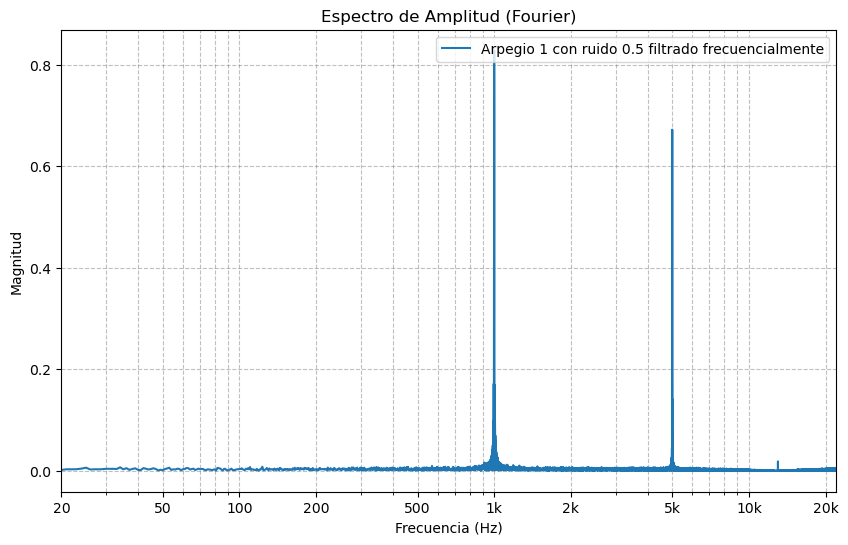

In [28]:
arpegio1_05_filtrado_frec = filtrar_frecuencial(h_peine, arpegio1_ruido05,fs2)
graficar_f(fs2, arpegio1_05_filtrado_frec, 'Arpegio 1 con ruido 0.5 filtrado frecuencialmente')

Se observa que ambos metodos de filtrado funcionan efectivamente y corresponden a lo esperado si se observa la respuesta en frecuencia del Filtro Peine (1, 0.5, 1). La frecuencia de 1000 Hz se amplifica por un modulo aproximadamente de 2.5, el tono de 5000 Hz tiene una amplificacion un poco menor y el tono de 13000 Hz, que se encuentra en la zona de atenuacion casi total, se ve practicamente atenuado.
A partir de ahora se utilizará solamente el método de filtrado por frecuencia, debido a que es más rápido y demanda menor cantidad de recursos al realizar menor cantidad de operaciones. 

##### SUMA DE TONOS PUROS CON RUIDO 0.5

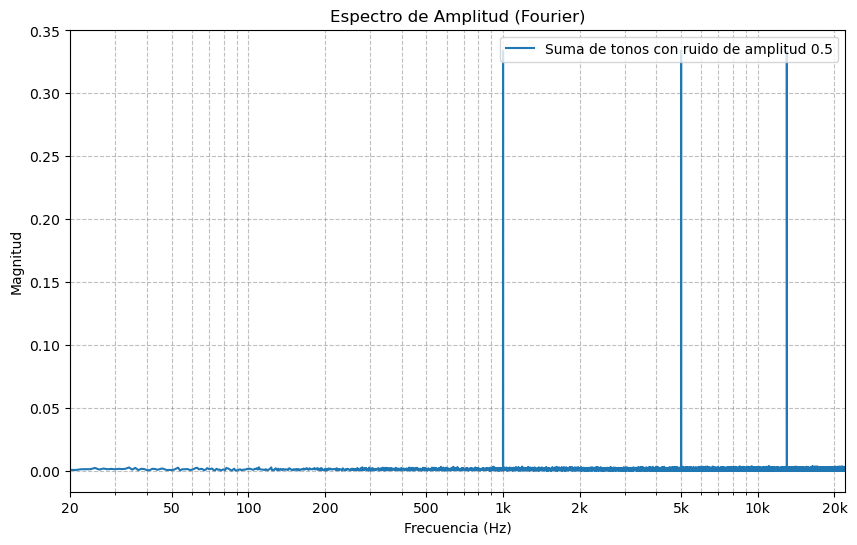

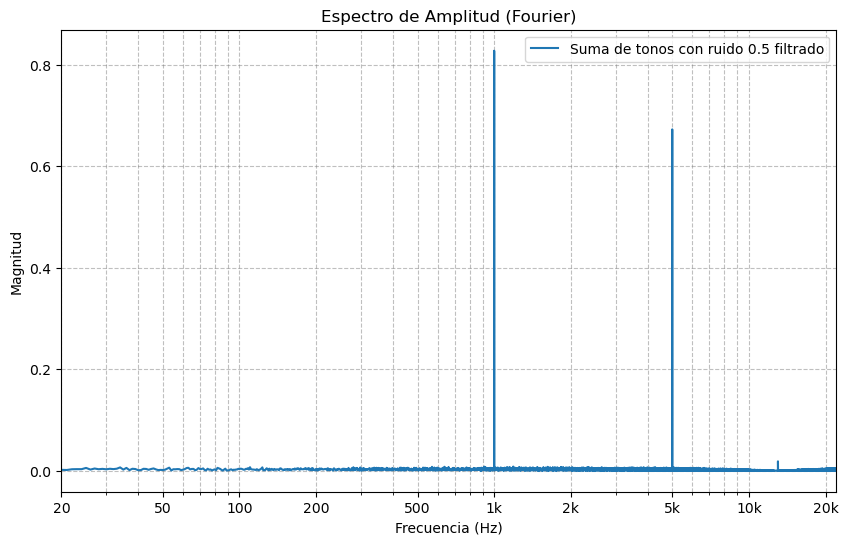

In [29]:
# SE SUMAN TRES SEÑALES DE TONOS PUROS DE 1 SEGUNDO CON RUIDO DE AMPLITUD 0.5 Y SE LA FILTRA UTILIZANDO LA RESPUESTA AL IMPULSO DEL FILTRO PEINE (1, 0.5, 1).
tono1 = generar_tono_puro(1/3, 1, fs2, 1000)
tono2 = generar_tono_puro(1/3, 1, fs2, 5000)
tono3 = generar_tono_puro(1/3, 1, fs2, 13000)
sumatono_ruido05 = sumar_senales(tono1, tono2, tono3, ruido_blanco_05)
tonos_05_filtrado = filtrar_frecuencial(h_peine, sumatono_ruido05, fs2)

# SE GRAFICA LA SENAL SIN FILTRAR Y LA SENAL FILTRADA.
graficar_f(fs2, sumatono_ruido05, 'Suma de tonos con ruido de amplitud 0.5')
graficar_f(fs2, tonos_05_filtrado, 'Suma de tonos con ruido 0.5 filtrado')


Al sumar los mismos tonos que estaban presentes en la señal musical (arpegio), el resultado en el espectro es el mismo ya que este análisis frecuencial no distingue la temporalidad de aparición de cada frecuencia. 

##### SEÑAL MUSICAL CON RUIDO DE AMPLITUD 1

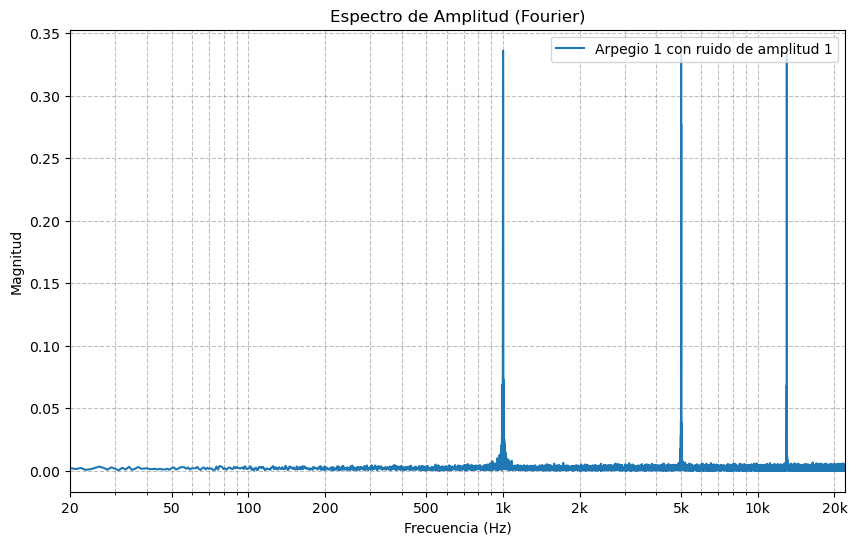

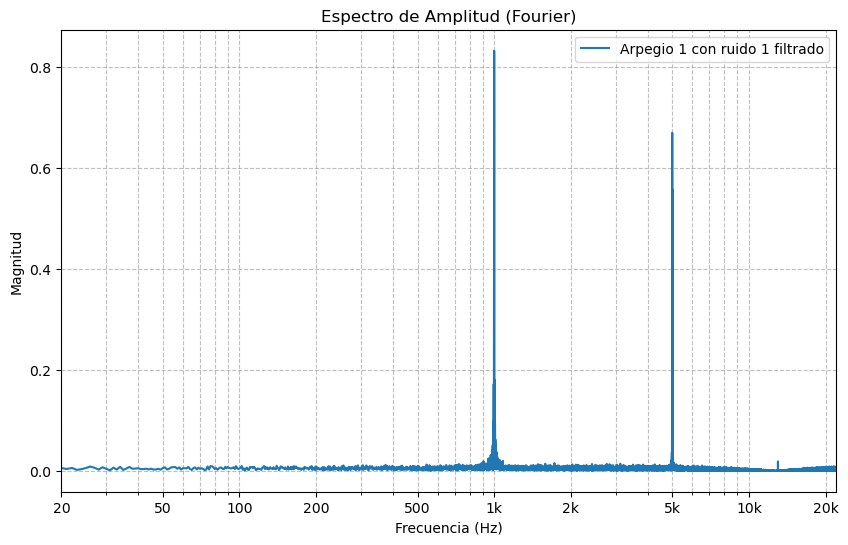

In [30]:
# SE GENERA UNA SEÑAL DE ARPEGIO DE 1 SEGUNDO CON RUIDO DE AMPLITUD 1 Y SE LA FILTRA UTILIZANDO LA RESPUESTA AL IMPULSO DEL FILTRO PEINE (1, 0.5, 1).
ruido_blanco_1= generar_ruido_blanco(amplitud=1, duracion=1, fs=fs2)
arpegio1 = generar_arpegio(1, fs2, 1000, 5000, 13000)
arpegio1_ruido1 = sumar_senales(arpegio1, ruido_blanco_1)
arpegio1_1_filtrado = filtrar_frecuencial(h_peine, arpegio1_ruido1, fs=fs2)

# SE GRAFICA LA SENAL SIN FILTRAR Y LA SENAL FILTRADA.
graficar_f(fs2, arpegio1_ruido1, 'Arpegio 1 con ruido de amplitud 1')
graficar_f(fs2, arpegio1_1_filtrado, 'Arpegio 1 con ruido 1 filtrado')

Aumentando la amplitud del ruido, se puede notar de manera más clara que el contenido del ruido alrededor de 8k Hz también se atenúa, debido a la magnitud de la respuesta en frecuencia del filtro utilizado. 

##### SUMA DE TONOS PUROS CON RUIDO DE AMPLITUD 1

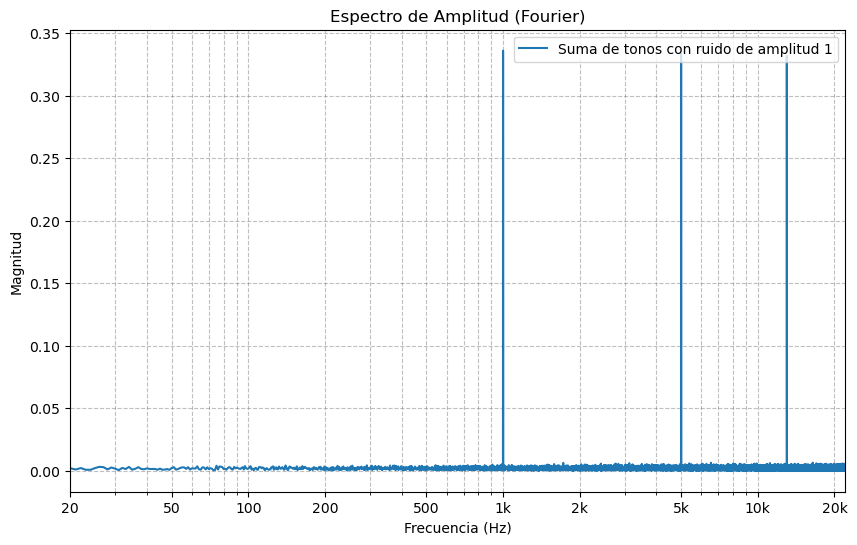

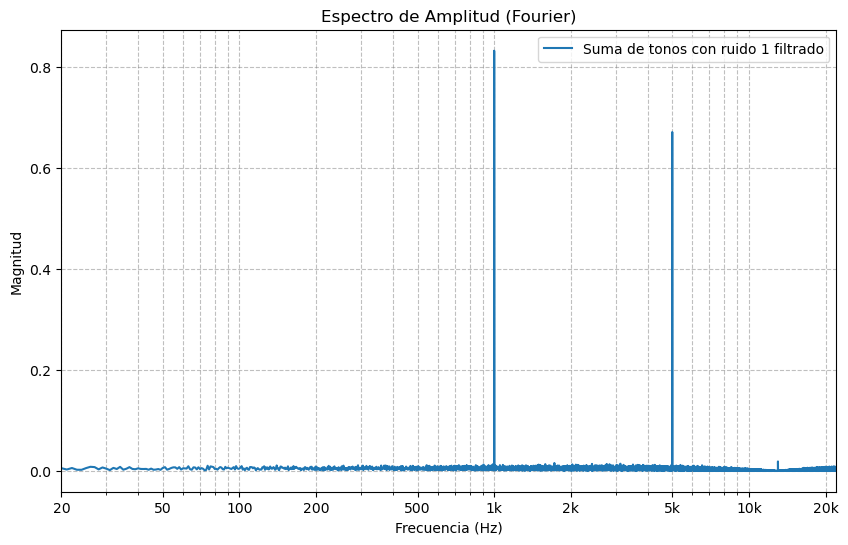

In [31]:
# SE SUMAN TRES SEÑALES DE TONOS PUROS DE 1 SEGUNDO CON RUIDO DE AMPLITUD 1 Y SE LA FILTRA UTILIZANDO LA RESPUESTA AL IMPULSO DEL FILTRO PEINE (1, 0.5, 1).
sumatono_ruido1 = sumar_senales(tono1, tono2, tono3, ruido_blanco_1)
tonos_1_filtrado = filtrar_frecuencial(h_peine, sumatono_ruido1, fs2)

# SE GRAFICA LA SENAL SIN FILTRAR Y LA SENAL FILTRADA.
graficar_f(fs2, sumatono_ruido1, 'Suma de tonos con ruido de amplitud 1')
graficar_f(fs2, tonos_1_filtrado, 'Suma de tonos con ruido 1 filtrado')

A partir del comportamiento observado, a continuación se filtrará solamente la señal de arpegio con ruido de amplitud 1, con el método frecuencial. 

#### FILTRADO UTILIZANDO EL FILTRO MEDIA MÓVIL

Se filtrará el mismo arpegio utilizado para el análisis del filtro peine. 

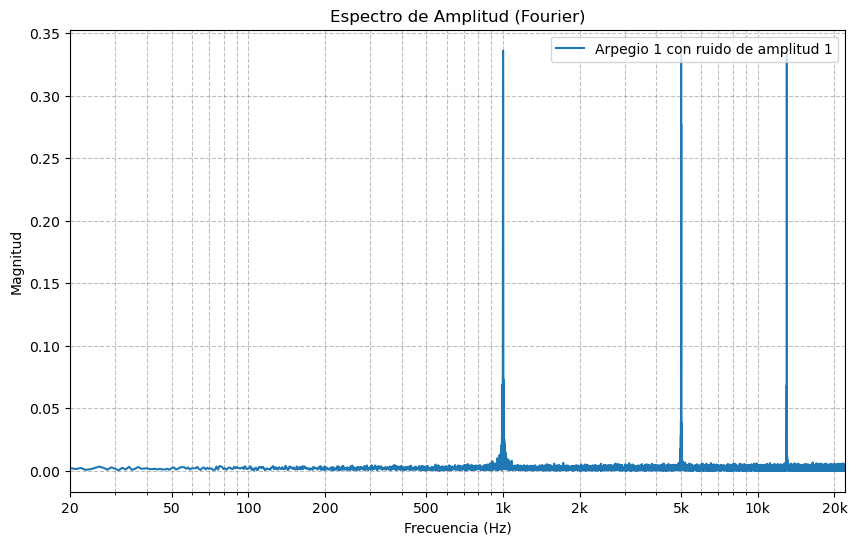

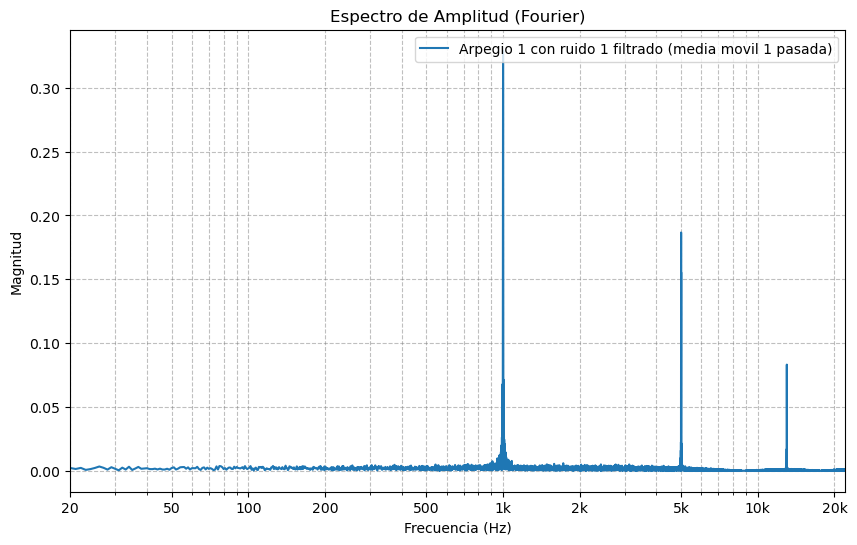

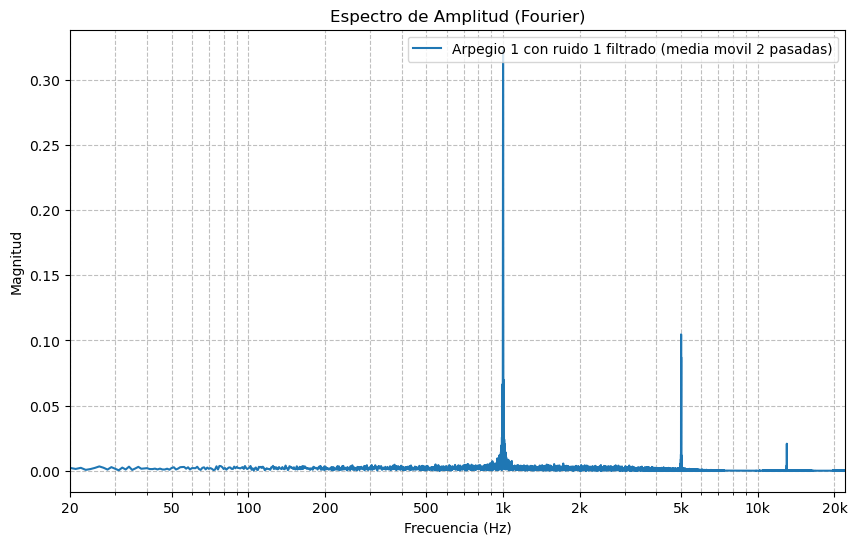

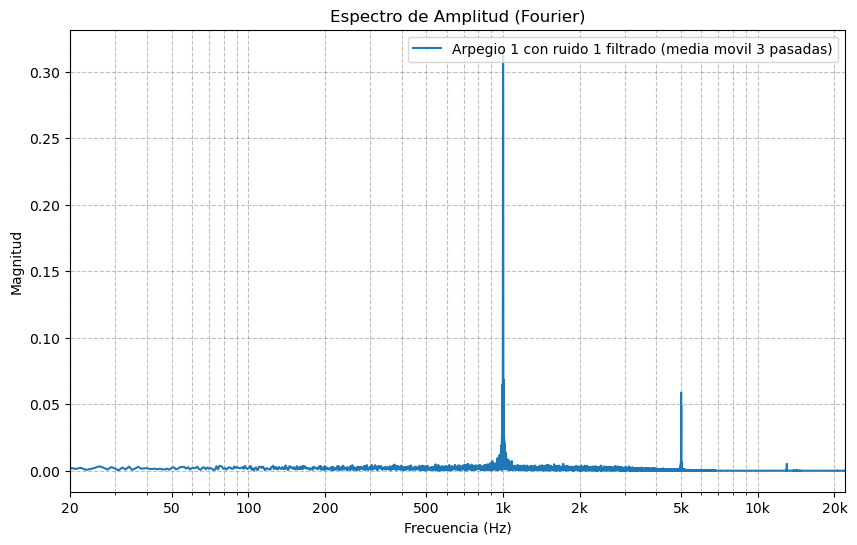

In [32]:
arpegio1_1_filtradoh1 = filtrar_frecuencial(h1, arpegio1_ruido1, fs=fs2)
arpegio1_1_filtradoh2 = filtrar_frecuencial(h2, arpegio1_ruido1, fs=fs2)
arpegio1_1_filtradoh3 = filtrar_frecuencial(h3, arpegio1_ruido1, fs=fs2)

# SE GRAFICA LA SENAL SIN FILTRAR Y LA SENAL FILTRADA.
graficar_f(fs2, arpegio1_ruido1, 'Arpegio 1 con ruido de amplitud 1')
graficar_f(fs2, arpegio1_1_filtradoh1, 'Arpegio 1 con ruido 1 filtrado (media movil 1 pasada)')
graficar_f(fs2, arpegio1_1_filtradoh2, 'Arpegio 1 con ruido 1 filtrado (media movil 2 pasadas)')
graficar_f(fs2, arpegio1_1_filtradoh3, 'Arpegio 1 con ruido 1 filtrado (media movil 3 pasadas)')

Como se observaba al analizar el módulo del filtro, las pasadas provocan que la atenuación por encima de la banda de paso se vuelva cada vez más intensa, de modo que para el filtro de tres pasadas, el tono de 13 kHz está casi completamente atenuado.

#### FILTRADO UTILIZANDO EL FILTRO FIR

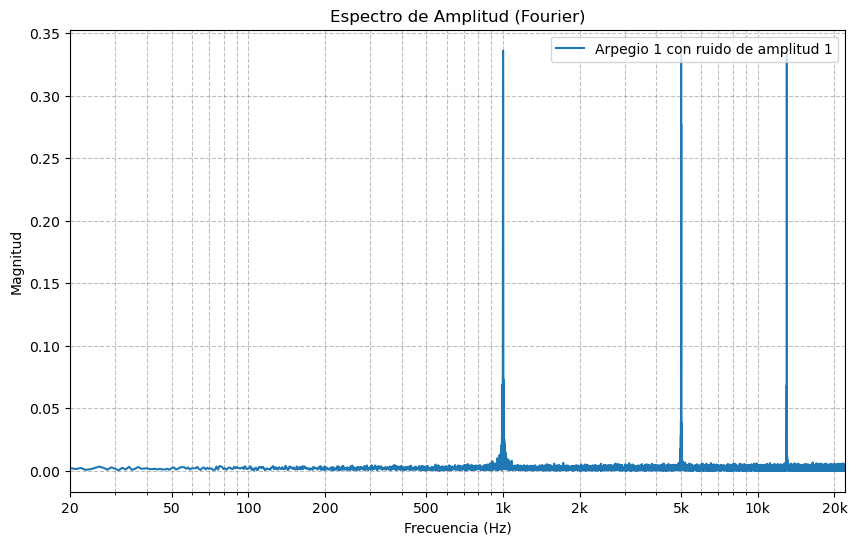

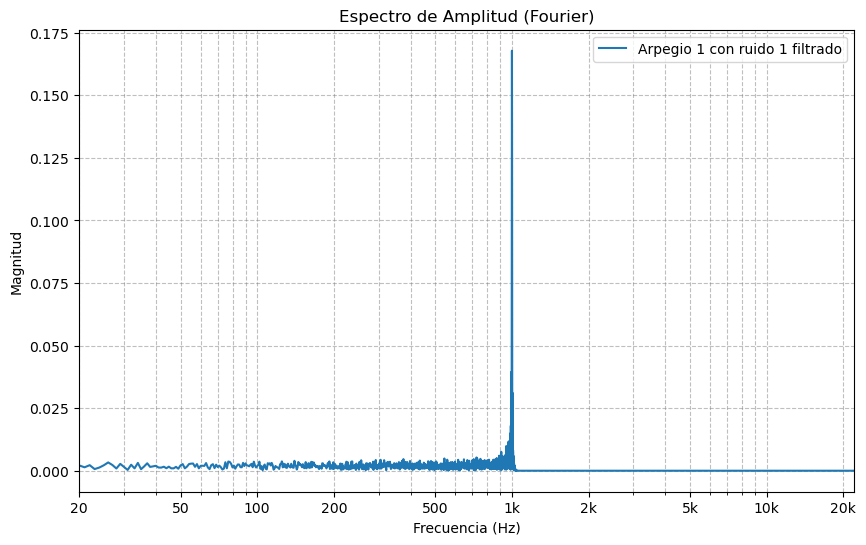

In [33]:
# SE GENERA UNA SEÑAL DE ARPEGIO DE 1 SEGUNDO CON RUIDO DE AMPLITUD 1 Y SE LA FILTRA UTILIZANDO LA RESPUESTA AL IMPULSO DEL FILTRO FIR
arpegio1_1_filtrado_fir = filtrar_frecuencial(h_fir, arpegio1_ruido1, fs=fs2)

# SE GRAFICA LA SENAL SIN FILTRAR Y LA SENAL FILTRADA.
graficar_f(fs2, arpegio1_ruido1, 'Arpegio 1 con ruido de amplitud 1')
graficar_f(fs2, arpegio1_1_filtrado_fir, 'Arpegio 1 con ruido 1 filtrado')

Se observa que se anulan las frecuencias (y el contenido de ruido) por encima de 1 kHz, lo cual coincide con el comportamiento esperable al observar el módulo de la respuesta en frecuencia del filtro pasabajos. A continuación, se ingresa un arpegio con contenido por debajo de 1 kHz. 

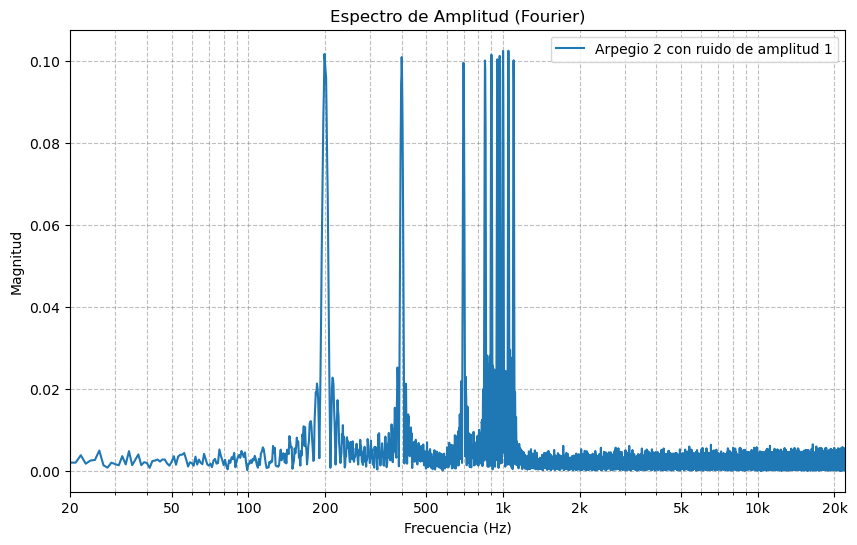

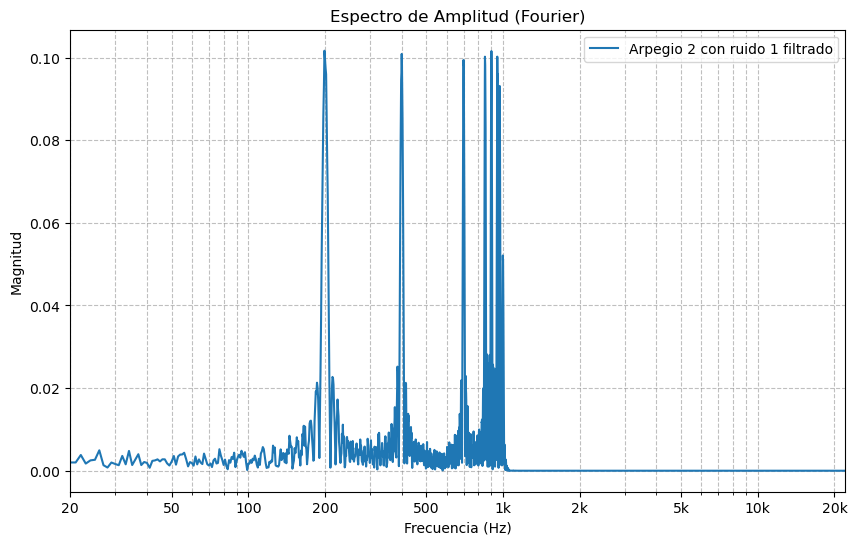

In [34]:
# SE GENERA OTRO ARPEGIO DE 1 SEGUNDO CON RUIDO DE AMPLITUD 1 Y SE LA FILTRA UTILIZANDO LA RESPUESTA AL IMPULSO DEL FILTRO FIR
arpegio1_LF = generar_arpegio(1, fs2, 200, 400, 700, 850, 900, 950, 970, 1000, 1050, 1100)
arpegio1_ruido1_LF = sumar_senales (arpegio1_LF, ruido_blanco_1)
arpegio1_1_filtrado_fir = filtrar_frecuencial(h_fir, arpegio1_ruido1_LF, fs=fs2)

# SE GRAFICA LA SENAL SIN FILTRAR Y LA SENAL FILTRADA.
graficar_f(fs2, arpegio1_ruido1_LF, 'Arpegio 2 con ruido de amplitud 1')
graficar_f(fs2, arpegio1_1_filtrado_fir, 'Arpegio 2 con ruido 1 filtrado')

Las frecuencias por debajo de 1 kHz mantienen su amplitud. Puede observarse la pendiente abrupta del filtro. Para ilustrar esto, se aplicare el filtro a una señal de ruido. 

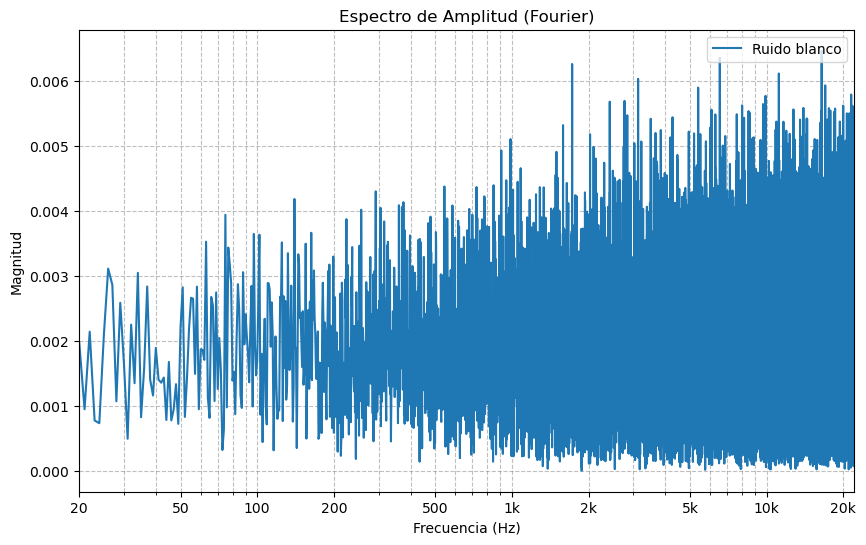

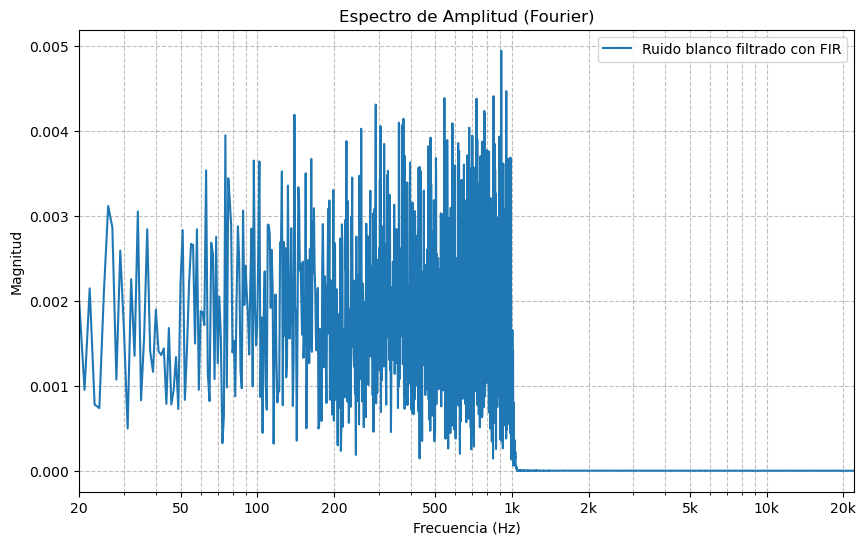

In [35]:
# SE FILTRA EL RUIDO UTILIZANDO LA RESPUESTA AL IMPULSO DEL FILTRO FIR
ruido_filtrado_fir = filtrar_frecuencial(h_fir, ruido_blanco_1, fs=fs2)

# SE GRAFICA LA SENAL SIN FILTRAR Y LA SENAL FILTRADA.
graficar_f(fs2, ruido_blanco_1, 'Ruido blanco')
graficar_f(fs2, ruido_filtrado_fir, 'Ruido blanco filtrado con FIR')

#### 1.6 TRUNCAR FIR

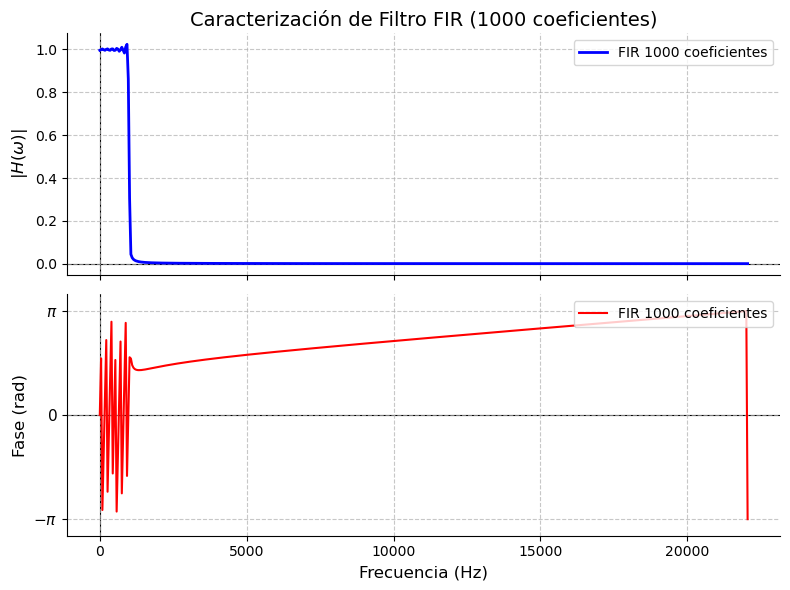

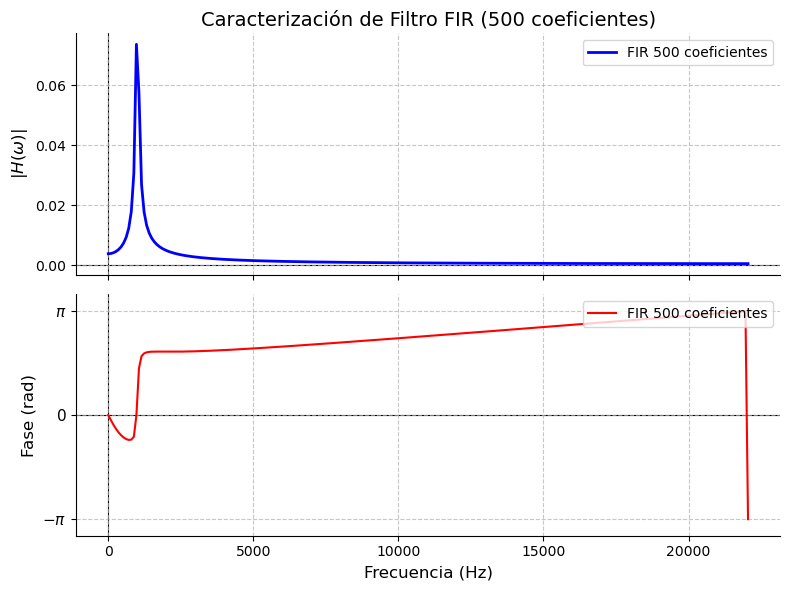

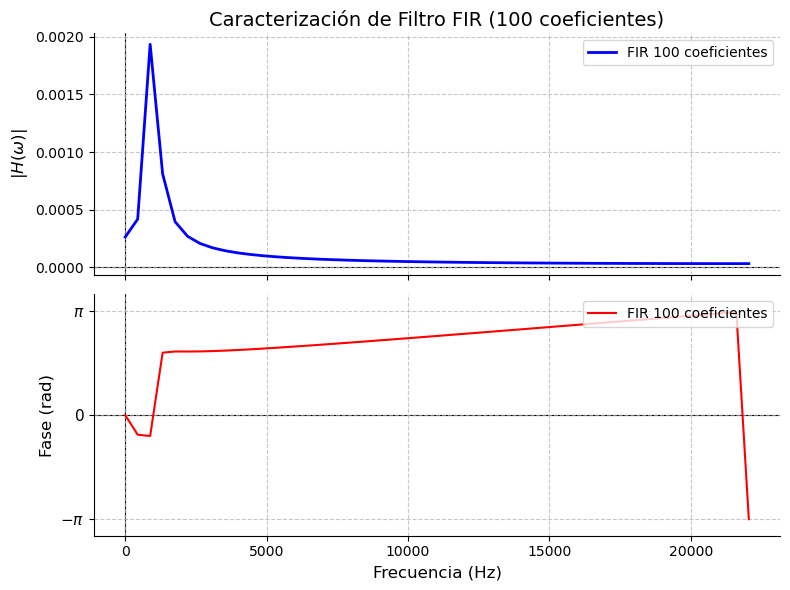

In [36]:
fir_og = filtro_fir(N=3000,path='Datos\\archivos_tp1c2026\\fir_hamming_1000Hz.npy')
fir_1000 = filtro_fir(N=1000,path='Datos\\archivos_tp1c2026\\fir_hamming_1000Hz.npy')
fir_500 = filtro_fir(N=500,path='Datos\\archivos_tp1c2026\\fir_hamming_1000Hz.npy')
fir_100 = filtro_fir(N=100,path='Datos\\archivos_tp1c2026\\fir_hamming_1000Hz.npy')

# graficar_t(fs2, señales=[fir_og], etiquetas=['FIR original'], titulo='Respuesta al impulso de filtro FIR (distintos coeficientes)', xlim=(0,0.05))
# graficar_t(fs2, señales=[fir_1000], etiquetas=['FIR 1000 coeficientes'], titulo='Respuesta al impulso de filtro FIR (distintos coeficientes)', xlim=(0,0.05))
# graficar_t(fs2, señales=[fir_500], etiquetas=['FIR 500 coeficientes'], titulo='Respuesta al impulso de filtro FIR (distintos coeficientes)', xlim=(0,0.05))
# graficar_t(fs2, señales=[fir_100], etiquetas=['FIR 100 coeficientes'], titulo='Respuesta al impulso de filtro FIR (distintos coeficientes)', xlim=(0,0.05))

freq_fir_1000, mod_fir_1000, fase_fir_1000 = analisis_filtros(fir_1000, fs2) 
graficar_analisis(freq_fir_1000, mod_fir_1000, fase_fir_1000 , etiquetas='FIR 1000 coeficientes', titulo='Caracterización de Filtro FIR (1000 coeficientes)')
freq_fir_500, mod_fir_500, fase_fir_500 = analisis_filtros(fir_500, fs2)
graficar_analisis(freq_fir_500, mod_fir_500, fase_fir_500 , etiquetas='FIR 500 coeficientes', titulo='Caracterización de Filtro FIR (500 coeficientes)')
freq_fir_100, mod_fir_100, fase_fir_100 = analisis_filtros(fir_100, fs2)
graficar_analisis(freq_fir_100, mod_fir_100, fase_fir_100 , etiquetas='FIR 100 coeficientes', titulo='Caracterización de Filtro FIR (100 coeficientes)')


Al truncar la cantidad de coeficientes del filtro FIR, la respuesta al impulso (antes con comportamiento de tipo sinc) se ve recortada. Por ende, en el análisis frecuencial se observa que el filtro va perdiendo su forma de pasa bajos.

# VER DE COMPARAR ENTRE UN FILTRO DE UN PAR DE MUESTRAS Y EL FIR QUE TIENE 1400 !!!!!

In [37]:
import time

# Hacer múltiples ejecuciones para obtener tiempos más precisos
num_iteraciones = 10

# Medición del tiempo de filtrado temporal (múltiples pasadas)
inicio_temporal = time.time()
for _ in range(num_iteraciones):
    resultado_temporal = filtrar_temporal(h_peine, arpegio1_ruido05)
tiempo_temporal_total = time.time() - inicio_temporal
tiempo_temporal = tiempo_temporal_total / num_iteraciones

# Medición del tiempo de filtrado frecuencial (múltiples pasadas)
inicio_frecuencial = time.time()
for _ in range(num_iteraciones):
    resultado_frecuencial = filtrar_frecuencial(h_peine, arpegio1_ruido05, fs2)
tiempo_frecuencial_total = time.time() - inicio_frecuencial
tiempo_frecuencial = tiempo_frecuencial_total / num_iteraciones

# Mostrar resultados
print(f"Resultados promedio ({num_iteraciones} iteraciones cada uno):\n")
print(f"Tiempo filtrado temporal: {tiempo_temporal:.6f} segundos")
print(f"Tiempo filtrado frecuencial: {tiempo_frecuencial:.6f} segundos")
print(f"\nDiferencia: {abs(tiempo_temporal - tiempo_frecuencial):.6f} segundos")

if tiempo_frecuencial > 0:
    ratio = tiempo_temporal / tiempo_frecuencial
    print(f"Ratio (temporal/frecuencial): {ratio:.2f}x")
    
    if tiempo_frecuencial < tiempo_temporal:
        print(f"\nEl filtrado frecuencial es {ratio:.2f}x más rápido")
    else:
        print(f"\nEl filtrado temporal es {(1/ratio):.2f}x más rápido")
else:
    print("El filtrado frecuencial es significativamente más rápido (tiempo medido < 1 microsegundo)")

Resultados promedio (10 iteraciones cada uno):

Tiempo filtrado temporal: 0.006667 segundos
Tiempo filtrado frecuencial: 0.005558 segundos

Diferencia: 0.001109 segundos
Ratio (temporal/frecuencial): 1.20x

El filtrado frecuencial es 1.20x más rápido
